In [ ]:
import os
import subprocess

ON_ROOT = os.path.expanduser("~/Downloads/UCLA_dataset")

print(f" Checking dataset contents at: {ON_ROOT}\n")

def run_cmd(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    return result.stdout.strip()


t1w_count = run_cmd(f'find "{ON_ROOT}" -name "*_T1w.nii*" | wc -l')
dwi_count = run_cmd(f'find "{ON_ROOT}" -name "*_dwi.nii*" | wc -l')
bold_count = run_cmd(f'find "{ON_ROOT}" -name "*task-rest_bold.nii*" | wc -l')
phenotype_count = run_cmd(f'ls "{ON_ROOT}/phenotype" 2>/dev/null | wc -l')

print(f"T1w (anatomical MRI) files: {t1w_count}")
print(f"DWI (diffusion) files:      {dwi_count}")
print(f"fMRI (resting-state) files: {bold_count}")
print(f"Phenotype TSVs:             {phenotype_count}")

print("\n📄 Example phenotype files:")
print(run_cmd(f'ls "{ON_ROOT}/phenotype" | head -10'))

 Checking dataset contents at: /Users/fatimazahra/Downloads/UCLA_dataset

T1w (anatomical MRI) files: 223
DWI (diffusion) files:      220
fMRI (resting-state) files: 224
Phenotype TSVs:             104

📄 Example phenotype files:
acds_adult.json
acds_adult.tsv
adhd.json
adhd.tsv
admin.json
admin.tsv
ant.json
ant.tsv
asrs.json
asrs.tsv


In [ ]:
import pandas as pd, os, glob, re

DATA_ROOT = os.path.expanduser("~/Downloads/UCLA_dataset")

parts = pd.read_csv(os.path.join(DATA_ROOT, "participants.tsv"), sep="\t")
print(f"participants.tsv shape: {parts.shape}")
print(parts.head())

subs = sorted([re.search(r"(sub-\d+)", s).group(1)
               for s in glob.glob(os.path.join(DATA_ROOT, "sub-*"))
               if re.search(r"(sub-\d+)", s)])
print(f"\nFound {len(subs)} subject folders.")
print("First few subjects:", subs[:5])

participants.tsv shape: (272, 16)
  participant_id diagnosis  age gender  bart  bht  dwi  pamenc  pamret  rest  \
0      sub-10159   CONTROL   30      F   1.0  NaN  1.0     NaN     NaN   1.0   
1      sub-10171   CONTROL   24      M   1.0  1.0  1.0     NaN     NaN   1.0   
2      sub-10189   CONTROL   49      M   1.0  NaN  1.0     NaN     NaN   1.0   
3      sub-10193   CONTROL   40      M   1.0  NaN  1.0     NaN     NaN   NaN   
4      sub-10206   CONTROL   21      M   1.0  NaN  1.0     NaN     NaN   1.0   

   scap  stopsignal  T1w  taskswitch  ScannerSerialNumber ghost_NoGhost  
0   1.0         1.0  1.0         1.0              35343.0      No_ghost  
1   1.0         1.0  1.0         1.0              35343.0      No_ghost  
2   1.0         1.0  1.0         1.0              35343.0      No_ghost  
3   NaN         NaN  1.0         NaN              35343.0      No_ghost  
4   1.0         1.0  1.0         1.0              35343.0      No_ghost  

Found 272 subject folders.
First few sub

In [ ]:
import pandas as pd, os, re, glob, numpy as np

DATA_ROOT = os.path.expanduser("~/Downloads/UCLA_dataset")

def read_tsv_safe(path):
    try:
        df = pd.read_csv(path, sep="\t")
        if "participant_id" not in df.columns:
            for c in df.columns:
                if re.search(r"(subject|participant).*id", c, re.I):
                    df = df.rename(columns={c:"participant_id"})
                    break
        df["participant_id"] = df["participant_id"].astype(str)
        df["participant_id"] = df["participant_id"].apply(lambda s: s if s.startswith("sub-") else f"sub-{s}")
        return df
    except Exception:
        return None

parts = read_tsv_safe(os.path.join(DATA_ROOT, "participants.tsv"))

pheno_paths = {os.path.basename(p): p for p in glob.glob(os.path.join(DATA_ROOT, "phenotype", "*.tsv"))}

disorders = {
    "SCHZ": ["scid", "saps", "sans", "bprs"],
    "BP":   ["bipolar", "ymrs"],
    "ADHD": ["adhd", "asrs", "acds"],
    "CONTROL": ["health"]
}

labels = {}
for disorder, keys in disorders.items():
    matches = []
    for key in keys:
        for fname, path in pheno_paths.items():
            if key in fname.lower():
                df = read_tsv_safe(path)
                if df is not None:
                    ids = df["participant_id"].unique().tolist()
                    matches += ids
    for sid in matches:
        labels[sid] = disorder

parts["diagnosis_final"] = parts["participant_id"].map(labels).fillna("OTHER")

print("Diagnosis distribution:")
print(parts["diagnosis_final"].value_counts())

parts[["participant_id", "diagnosis_final", "age", "gender"]].head(10)


Diagnosis distribution:
diagnosis_final
CONTROL    272
Name: count, dtype: int64


,participant_id,diagnosis_final,age,gender
0,sub-10159,CONTROL,30,F
1,sub-10171,CONTROL,24,M
2,sub-10189,CONTROL,49,M
3,sub-10193,CONTROL,40,M
4,sub-10206,CONTROL,21,M
5,sub-10217,CONTROL,33,F
6,sub-10225,CONTROL,35,M
7,sub-10227,CONTROL,31,F
8,sub-10228,CONTROL,40,F
9,sub-10235,CONTROL,22,M


In [ ]:
import pandas as pd, os, re, glob

DATA_ROOT = os.path.expanduser("~/Downloads/UCLA_dataset")

pattern = re.compile(r"(diagnosis|dx|group|condition|cohort)", re.I)
candidates = []
for p in sorted(glob.glob(os.path.join(DATA_ROOT, "phenotype", "*.tsv"))):
    try:
        df = pd.read_csv(p, sep="\t")
        hit_cols = [c for c in df.columns if pattern.search(c)]
        if hit_cols:
            nuniq = {c: df[c].nunique() for c in hit_cols}
            candidates.append((os.path.basename(p), hit_cols, nuniq))
    except Exception:
        continue

print("Possible diagnostic phenotype files:")
for name, cols, uniq in candidates:
    print(f" - {name:25s} | cols: {cols} | uniques: {uniq}")


Possible diagnostic phenotype files:
 - acds_adult.tsv            | cols: ['adhd_c_dx', 'adhd_f_child_dx'] | uniques: {'adhd_c_dx': 2, 'adhd_f_child_dx': 2}
 - scid.tsv                  | cols: ['scid_dxdefs5', 'scid_dxdefs6', 'scid_dx2', 'scid_dxdef1', 'scid_dx4', 'scid_dxdefs8', 'scid_dxdef6', 'scid_dxdef7', 'scid_dx1', 'scid_dxdefs3', 'scid_dxdefs7', 'scid_dx6', 'scid_dxdef5', 'scid_dxdefs2', 'scid_dx7', 'scid_dx8', 'scid_dxdef2', 'scid_dxdef8', 'scid_dxdefs1', 'scid_dx5', 'scid_dxdefs4', 'scid_dxdef4', 'scid_dxdef3', 'scid_dx3'] | uniques: {'scid_dxdefs5': 0, 'scid_dxdefs6': 0, 'scid_dx2': 28, 'scid_dxdef1': 0, 'scid_dx4': 18, 'scid_dxdefs8': 0, 'scid_dxdef6': 0, 'scid_dxdef7': 0, 'scid_dx1': 38, 'scid_dxdefs3': 0, 'scid_dxdefs7': 0, 'scid_dx6': 13, 'scid_dxdef5': 0, 'scid_dxdefs2': 1, 'scid_dx7': 11, 'scid_dx8': 11, 'scid_dxdef2': 1, 'scid_dxdef8': 0, 'scid_dxdefs1': 0, 'scid_dx5': 12, 'scid_dxdefs4': 0, 'scid_dxdef4': 0, 'scid_dxdef3': 0, 'scid_dx3': 26}


In [ ]:
import os, re, pandas as pd

DATA_ROOT = os.path.expanduser("~/Downloads/UCLA_dataset")
scid_path = os.path.join(DATA_ROOT, "phenotype", "scid.tsv")

scid = pd.read_csv(scid_path, sep="\t")
print("scid.tsv columns:\n", scid.columns.tolist(), "\n")

for c in scid.columns:
    if re.search(r"(diag|dx|group|condition|cohort|status)", c, re.I):
        vc = scid[c].astype(str).str.strip().str.upper().value_counts(dropna=False).head(15)
        print(f"== {c} ==")
        print(vc, "\n")



scid.tsv columns:
 ['participant_id', 'scid_sch6', 'scid_dep3', 'scid_dxdefs5', 'scid_sch3', 'scid_dep5', 'scid_anx6', 'scid_sch2', 'scid_alc2', 'scid_dxdefs6', 'scid_alc5', 'scid_dx2', 'scid_dxdef1', 'scid_dep1', 'scid_dep7', 'scid_dep2', 'scid_dx4', 'scid_anx4', 'scid_dxdefs8', 'scid_anx1', 'scid_alc1', 'scid_dxdef6', 'scid_dxdef7', 'scid_anx5', 'scid_dx1', 'scid_anx3', 'scid_dxdefs3', 'scid_dxdefs7', 'scid_alc7', 'scid_dep4', 'scid_sch1', 'scid_dx6', 'scid_alc8', 'scid_alc6', 'scid_dxdef5', 'scid_dxdefs2', 'scid_dx7', 'scid_dx8', 'scid_anx7', 'scid_alc3', 'scid_dxdef2', 'scid_sch5', 'scid_anx2', 'scid_dxdef8', 'scid_anx8', 'scid_sch8', 'scid_sch4', 'scid_alc4', 'scid_dxdefs1', 'scid_dx5', 'scid_dep8', 'scid_dxdefs4', 'scid_dxdef4', 'scid_dxdef3', 'scid_dep6', 'scid_sch7', 'scid_dx3'] 

== scid_dxdefs5 ==
scid_dxdefs5
NAN    272
Name: count, dtype: int64 

== scid_dxdefs6 ==
scid_dxdefs6
NAN    272
Name: count, dtype: int64 

== scid_dx2 ==
scid_dx2
NAN                               

In [ ]:
import os, re, glob, numpy as np, pandas as pd

DATA_ROOT = os.path.expanduser("~/Downloads/UCLA_dataset")
OUT_DIR = "./la5c_runs"
os.makedirs(OUT_DIR, exist_ok=True)

parts = pd.read_csv(os.path.join(DATA_ROOT, "participants.tsv"), sep="\t")
scid  = pd.read_csv(os.path.join(DATA_ROOT, "phenotype", "scid.tsv"), sep="\t")

def norm_pid(df):
    pid = None
    for c in df.columns:
        if re.search(r"(participant|subject).*id", c, re.I):
            pid = c; break
    if pid is None: raise RuntimeError("No participant_id column in df")
    if pid != "participant_id": df = df.rename(columns={pid:"participant_id"})
    df["participant_id"] = df["participant_id"].astype(str).apply(lambda s: s if s.startswith("sub-") else f"sub-{s}")
    return df
parts = norm_pid(parts)
scid  = norm_pid(scid)

dx_cols = [c for c in scid.columns if re.fullmatch(r"scid_dx\d+", c)]
if not dx_cols:
    raise RuntimeError("No scid_dxN columns found in scid.tsv")
dx_cols = sorted(dx_cols, key=lambda c: (c!="scid_dx1", c))

re_schz  = re.compile(r"(SCHIZ|295\.)", re.I)
re_bp    = re.compile(r"(BIPOLAR|SCHIZOAFFECTIVE|296\.(4|5|6|7|8))", re.I)  # BP + schizoaffective to BP bucket
re_adhd  = re.compile(r"(ADHD|ATTENTION-DEFICIT|314\.)", re.I)
re_ctrl  = re.compile(r"(NO\s*DIAGNOSIS|V71\.09|HEALTHY|CONTROL|NORMAL)", re.I)

def pick_label(row):
    vals = []
    for c in dx_cols:
        v = str(row.get(c, "")).strip()
        if v and v.upper() != "NAN":
            vals.append(v)
    txt = " | ".join(vals)
    if re_schz.search(txt): return "SCHZ"
    if re_bp.search(txt):   return "BP"
    if re_adhd.search(txt): return "ADHD"
    if re_ctrl.search(txt): return "CONTROL"
    return "OTHER"

scid_labels = scid[["participant_id"] + dx_cols].copy()
scid_labels["diagnosis_final"] = scid_labels.apply(pick_label, axis=1)

def ids_from_patterns(patterns):
    hits = set()
    for p in glob.glob(os.path.join(DATA_ROOT, "phenotype", "*.tsv")):
        base = os.path.basename(p).lower()
        if any(k in base for k in patterns):
            d = pd.read_csv(p, sep="\t")
            pid = [c for c in d.columns if re.search(r"(participant|subject).*id", c, re.I)]
            if not pid: continue
            pid = pid[0]
            ids = d[pid].astype(str).apply(lambda s: s if s.startswith("sub-") else f"sub-{s}")
            hits |= set(ids.tolist())
    return hits

schz_ids = ids_from_patterns(["saps","sans","bprs"])
bp_ids   = ids_from_patterns(["bipolar","ymrs"])
adhd_ids = ids_from_patterns(["adhd","asrs","acds"])
ctrl_ids = ids_from_patterns(["health"])

def upgrade(row):
    sid = row["participant_id"]
    lab = row["diagnosis_final"]
    if lab != "OTHER":  
        return lab
    if sid in schz_ids: return "SCHZ"
    if sid in bp_ids:   return "BP"
    if sid in adhd_ids: return "ADHD"
    if sid in ctrl_ids: return "CONTROL"
    return "OTHER"

scid_labels["diagnosis_final"] = scid_labels.apply(upgrade, axis=1)

merged = parts.merge(scid_labels[["participant_id","diagnosis_final"]], on="participant_id", how="left")
merged["diagnosis_final"] = merged["diagnosis_final"].fillna("OTHER")

print("Diagnosis distribution (final):")
print(merged["diagnosis_final"].value_counts(dropna=False))
display(merged[["participant_id","diagnosis_final","age","gender"]].head(12))

merged.to_csv(os.path.join(OUT_DIR, "labels_full.csv"), index=False)


Diagnosis distribution (final):
diagnosis_final
SCHZ       114
CONTROL     66
BP          50
ADHD        42
Name: count, dtype: int64


,participant_id,diagnosis_final,age,gender
0,sub-10159,CONTROL,30,F
1,sub-10171,SCHZ,24,M
2,sub-10189,SCHZ,49,M
3,sub-10193,SCHZ,40,M
4,sub-10206,SCHZ,21,M
5,sub-10217,CONTROL,33,F
6,sub-10225,SCHZ,35,M
7,sub-10227,SCHZ,31,F
8,sub-10228,SCHZ,40,F
9,sub-10235,CONTROL,22,M


In [ ]:
label_df = merged[["participant_id", "diagnosis_final", "age", "gender"]].copy()
label_df.to_csv("./la5c_runs/labels_ready.csv", index=False)

print(" Saved clean labels to ./la5c_runs/labels_ready.csv")
print(label_df["diagnosis_final"].value_counts())
label_df.head(10)

 Saved clean labels to ./la5c_runs/labels_ready.csv
diagnosis_final
SCHZ       114
CONTROL     66
BP          50
ADHD        42
Name: count, dtype: int64


,participant_id,diagnosis_final,age,gender
0,sub-10159,CONTROL,30,F
1,sub-10171,SCHZ,24,M
2,sub-10189,SCHZ,49,M
3,sub-10193,SCHZ,40,M
4,sub-10206,SCHZ,21,M
5,sub-10217,CONTROL,33,F
6,sub-10225,SCHZ,35,M
7,sub-10227,SCHZ,31,F
8,sub-10228,SCHZ,40,F
9,sub-10235,CONTROL,22,M


In [8]:
!pip install -q numpy pandas scikit-learn imbalanced-learn nibabel nilearn \
               torch torchvision torchaudio tqdm matplotlib \
               grad-cam

In [9]:
from pytorch_grad_cam import GradCAM
print("GradCAM imported successfully")

GradCAM imported successfully


In [10]:
import os, re, glob, random, json, math, copy, warnings
import numpy as np, pandas as pd
from tqdm import tqdm
warnings.filterwarnings("ignore")

DATA_ROOT = os.path.expanduser("~/Downloads/UCLA_Dataset")
OUT_DIR   = "./la5c_runs"
os.makedirs(OUT_DIR, exist_ok=True)

labels_path = os.path.join(OUT_DIR, "labels_ready.csv")
if not os.path.exists(labels_path):
    labels_path = os.path.join(OUT_DIR, "labels_full.csv")
labels = pd.read_csv(labels_path)

subs_on_disk = {os.path.basename(p) for p in glob.glob(os.path.join(DATA_ROOT, "sub-*"))}
labels = labels[labels["participant_id"].isin(subs_on_disk)].copy()

def first_file(pattern):
    fs = glob.glob(pattern)
    return fs[0] if fs else None

index = []
for sid in labels["participant_id"]:
    t1w = first_file(os.path.join(DATA_ROOT, sid, "anat", f"{sid}_*T1w.nii*"))
    dwi = first_file(os.path.join(DATA_ROOT, sid, "dwi",  f"{sid}_*dwi.nii*"))
    bval= first_file(os.path.join(DATA_ROOT, sid, "dwi",  f"{sid}_*dwi.bval"))
    bvec= first_file(os.path.join(DATA_ROOT, sid, "dwi",  f"{sid}_*dwi.bvec"))
    index.append({"participant_id":sid, "t1w":t1w, "dwi":dwi, "bval":bval, "bvec":bvec})

index = pd.DataFrame(index)
df = labels.merge(index, on="participant_id", how="left")
df = df[df["t1w"].notna()].reset_index(drop=True)  # require T1w
print(df["diagnosis_final"].value_counts())
df.head(3)


diagnosis_final
SCHZ       111
CONTROL     64
BP          48
Name: count, dtype: int64


,participant_id,diagnosis_final,age,gender,t1w,dwi,bval,bvec
0,sub-10159,CONTROL,30,F,/Users/fatimazahra/Downloads/UCLA_Dataset/sub-...,/Users/fatimazahra/Downloads/UCLA_Dataset/sub-...,/Users/fatimazahra/Downloads/UCLA_Dataset/sub-...,/Users/fatimazahra/Downloads/UCLA_Dataset/sub-...
1,sub-10171,SCHZ,24,M,/Users/fatimazahra/Downloads/UCLA_Dataset/sub-...,/Users/fatimazahra/Downloads/UCLA_Dataset/sub-...,/Users/fatimazahra/Downloads/UCLA_Dataset/sub-...,/Users/fatimazahra/Downloads/UCLA_Dataset/sub-...
2,sub-10189,SCHZ,49,M,/Users/fatimazahra/Downloads/UCLA_Dataset/sub-...,/Users/fatimazahra/Downloads/UCLA_Dataset/sub-...,/Users/fatimazahra/Downloads/UCLA_Dataset/sub-...,/Users/fatimazahra/Downloads/UCLA_Dataset/sub-...


In [11]:

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["y_int"] = le.fit_transform(df["diagnosis_final"])
cls_names = list(le.classes_)      
n_classes = len(cls_names)
print("Classes:", cls_names, "| n_classes:", n_classes)


Classes: ['BP', 'CONTROL', 'SCHZ'] | n_classes: 3


In [12]:
import numpy as np, torch, torch.nn as nn, torch.optim as optim
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

counts = df["y_int"].value_counts().sort_index().values.astype(np.float32)
class_weights = (counts.max() / counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("Class weights:", class_weights.detach().cpu().numpy())

n_classes = len(cls_names)  


Using device: cpu
Class weights: [2.3125   1.734375 1.      ]


In [ ]:
import numpy as np
import torch
import pandas as pd
import torchvision.transforms as T

def gender_to_num(g):
    s = str(g).strip().upper()
    if s.startswith("M"): return 1.0
    if s.startswith("F"): return 0.0
    return 0.5  

class SliceSet(torch.utils.data.Dataset):
    def __init__(self, rows):
        self.rows = rows.reset_index(drop=True)
        self.items = []
        self.norm = T.Normalize(mean=[0.5]*3, std=[0.5]*3)
        for _, r in self.rows.iterrows():
            age = float(pd.to_numeric(r.get("age"), errors="coerce")) if "age" in r else np.nan
            sex = gender_to_num(r.get("gender")) if "gender" in r else 0.5
            age_f = np.nan_to_num(age, nan=0.0)
            sex_f = np.nan_to_num(sex, nan=0.5)
            tab = np.array([age_f, sex_f], dtype=np.float32)

            for sl in load_t1w_slices(r["t1w"]):
                x3 = np.stack([sl, sl, sl], axis=0)  # 3 channels
                self.items.append((x3, int(r["y_int"]), r["participant_id"], tab))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        x3, y, sid, tab = self.items[i]
        x = torch.from_numpy(x3).float()
        x = self.norm(x)
        t = torch.from_numpy(tab).float()
        return x, torch.tensor(y, dtype=torch.long), sid, t


In [15]:

import nibabel as nib
import numpy as np

def load_t1w_slices(path, max_slices=32, slice_axis=2):
    """
    Loads a 3D T1-weighted MRI NIfTI file and returns a list of normalized 2D slices.
    Parameters
    ----------
    path : str
        Path to .nii or .nii.gz file.
    max_slices : int
        Maximum number of slices to extract (for speed).
    slice_axis : int
        Axis to slice along (2 = axial default).
    """
    try:
        img = nib.load(path)
        data = img.get_fdata()
        # Normalize to [0,1]
        data = (data - np.min(data)) / (np.ptp(data) + 1e-8)
        # Pick evenly spaced slices
        total_slices = data.shape[slice_axis]
        idxs = np.linspace(0, total_slices - 1, max_slices).astype(int)
        slices = []
        for i in idxs:
            sl = np.take(data, i, axis=slice_axis)
            sl = np.clip(sl, 0, 1)
            slices.append(sl.astype(np.float32))
        return slices
    except Exception as e:
        print(f"[WARN] Failed to load {path}: {e}")
        return []



In [16]:
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import DataLoader
import numpy as np

SEED = 42
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
groups = df["participant_id"].values
y = df["y_int"].values
tr_idx, va_idx = next(sgkf.split(np.zeros(len(y)), y, groups))

train_rows = df.iloc[tr_idx].copy()
val_rows   = df.iloc[va_idx].copy()

train_ds = SliceSet(train_rows)
val_ds   = SliceSet(val_rows)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

print("Slices -> train:", len(train_ds), " | val:", len(val_ds))


Slices -> train: 5696  | val: 1440


In [17]:
import torch.nn as nn, torchvision
from torchvision.models import efficientnet_b0

class MultiModalEffNet(nn.Module):
    def __init__(self, n_classes, drop=0.3, pretrained=False):
        super().__init__()
        self.cnn = efficientnet_b0(weights=None if not pretrained else torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_f = self.cnn.classifier[1].in_features
        self.cnn.classifier[1] = nn.Identity()
        self.tab = nn.Sequential(
            nn.Linear(2,16), nn.ReLU(),
            nn.Linear(16,8)
        )
        self.head = nn.Sequential(
            nn.Dropout(drop),
            nn.Linear(in_f+8, 256), nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(256, n_classes)
        )
    def forward(self, x_img, x_tab):
        z_img = self.cnn(x_img)
        z_tab = self.tab(x_tab)
        z = torch.cat([z_img, z_tab], dim=1)
        return self.head(z)

In [ ]:
import torch, torch.optim as optim
from sklearn.preprocessing import LabelEncoder
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

counts = df["y_int"].value_counts().sort_index().values.astype(np.float32)
class_weights = torch.tensor((counts.max()/counts), dtype=torch.float32, device=DEVICE)
print("Class weights:", class_weights.cpu().numpy())

n_classes = len(cls_names)

from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, matthews_corrcoef
import numpy as np
from collections import defaultdict

def _softmax(z):
    z = z - z.max(axis=1, keepdims=True); e = np.exp(z); return e / e.sum(axis=1, keepdims=True)

def expected_calibration_error(probs, labels, M=15):
    conf = probs.max(axis=1); pred = probs.argmax(axis=1)
    correct = (pred==labels).astype(float)
    bins = np.linspace(0,1,M+1); ece=0.0
    for i in range(M):
        m = (conf>bins[i]) & (conf<=bins[i+1])
        if m.sum()==0: continue
        ece += (m.mean())*abs(correct[m].mean() - conf[m].mean())
    return float(ece)

def aggregate_subject(pred_logits, sids):
    bag=defaultdict(list)
    for logit,sid in zip(pred_logits,sids): bag[sid].append(logit)
    subs, logits = [], []
    for sid, arr in bag.items():
        subs.append(sid); logits.append(np.mean(np.stack(arr,0), axis=0))
    return subs, np.vstack(logits)

def evaluate_model(model, loader, n_classes):
    model.eval()
    all_logits, all_y, all_sid = [], [], []
    with torch.no_grad():
        for x,y,sid,tab in loader:
            x,tab = x.to(DEVICE), tab.to(DEVICE)
            out = model(x, tab)
            all_logits.append(out.detach().cpu().numpy())
            all_y.extend(y.numpy().tolist()); all_sid.extend(list(sid))
    all_logits = np.vstack(all_logits)
    subs, subj_logits = aggregate_subject(all_logits, all_sid)
    
    sid2y={}
    for _,y,sid,_ in loader.dataset:
        if sid not in sid2y: sid2y[sid]=int(y)
    subj_y = np.array([sid2y[s] for s in subs])

    probs = _softmax(subj_logits)
    y_bin = np.eye(n_classes)[subj_y]
    aucs, prs = [], []
    for c in range(n_classes):
        try:
            aucs.append(roc_auc_score(y_bin[:,c], probs[:,c]))
            prs.append(average_precision_score(y_bin[:,c], probs[:,c]))
        except Exception: pass
    mauc, mpr = float(np.mean(aucs)), float(np.mean(prs))
    yhat = probs.argmax(axis=1)
    mcc = matthews_corrcoef(subj_y, yhat)
    bacc = balanced_accuracy_score(subj_y, yhat)
    ece = expected_calibration_error(probs, subj_y)
    return {"macro_auc":mauc, "macro_pr":mpr, "mcc":mcc, "bacc":bacc, "ece":ece}

def train_one(model, train_loader, val_loader, epochs=6, lr=3e-4, wd=1e-5):
    model = model.to(DEVICE)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
    best_auc = -1.0; best_state=None
    for ep in range(1, epochs+1):
        model.train()
        for x,y,_,tab in train_loader:
            x,y,tab = x.to(DEVICE), y.to(DEVICE), tab.to(DEVICE)
            loss = criterion(model(x,tab), y)
            opt.zero_grad(); loss.backward(); opt.step()
        metrics = evaluate_model(model, val_loader, n_classes)
        print(f"Epoch {ep:02d} | AUC={metrics['macro_auc']:.3f} | PR={metrics['macro_pr']:.3f} | "
              f"MCC={metrics['mcc']:.3f} | BAcc={metrics['bacc']:.3f}")
        if metrics["macro_auc"] > best_auc:
            best_auc = metrics["macro_auc"]; best_state = {k:v.cpu() for k,v in model.state_dict().items()}
    if best_state is not None: model.load_state_dict(best_state)
    return model


Using device: cpu
Class weights: [2.3125   1.734375 1.      ]


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, matthews_corrcoef

def _softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z); return e / e.sum(axis=1, keepdims=True)

def expected_calibration_error(probs, labels, M=15):
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == labels).astype(float)
    bins = np.linspace(0,1,M+1)
    ece=0.0
    for i in range(M):
        m = (conf>bins[i]) & (conf<=bins[i+1])
        if m.sum()==0: continue
        ece += (m.mean())*abs(correct[m].mean() - conf[m].mean())
    return float(ece)

from collections import defaultdict
def aggregate_subject(pred_logits, sids):
    bag = defaultdict(list)
    for logit, sid in zip(pred_logits, sids):
        bag[sid].append(logit)
    subs, logits = [], []
    for sid, arr in bag.items():
        subs.append(sid)
        logits.append(np.mean(np.stack(arr,0), axis=0))
    return subs, np.vstack(logits)

def evaluate_model(model, loader, n_classes):
    model.eval()
    all_logits, all_y, all_sid = [], [], []
    with torch.no_grad():
        for x,y,sid,tab in loader:
            x, tab = x.to(DEVICE), tab.to(DEVICE)
            out = model(x, tab)
            all_logits.append(out.detach().cpu().numpy())
            all_y.extend(y.numpy().tolist()); all_sid.extend(list(sid))
    all_logits = np.vstack(all_logits)
    subs, subj_logits = aggregate_subject(all_logits, all_sid)
    sid2y = {}
    for _,y,sid,_ in loader.dataset:
        if sid not in sid2y: sid2y[sid]=int(y)
    subj_y = np.array([sid2y[s] for s in subs])

    probs = _softmax(subj_logits)
    y_bin = np.eye(n_classes)[subj_y]
    aucs, prs = [], []
    for c in range(n_classes):
        try:
            aucs.append(roc_auc_score(y_bin[:,c], probs[:,c]))
            prs.append(average_precision_score(y_bin[:,c], probs[:,c]))
        except Exception:
            pass
    mauc, mpr = float(np.mean(aucs)), float(np.mean(prs))
    yhat = probs.argmax(axis=1)
    mcc = matthews_corrcoef(subj_y, yhat)
    bacc = balanced_accuracy_score(subj_y, yhat)
    ece = expected_calibration_error(probs, subj_y)
    return {"macro_auc":mauc, "macro_pr":mpr, "mcc":mcc, "bacc":bacc, "ece":ece}, probs, subj_y


In [ ]:
def train_one(model, train_loader, val_loader, epochs=6, lr=3e-4, wd=1e-5):
    model = model.to(DEVICE)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_auc = -1.0
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        for x,y,_,tab in train_loader:
            x, y, tab = x.to(DEVICE), y.to(DEVICE), tab.to(DEVICE)
            logits = model(x, tab)
            loss = criterion(logits, y)
            opt.zero_grad(); loss.backward(); opt.step()

        metrics, _, _ = evaluate_model(model, val_loader, n_classes)
        print(f"Epoch {ep:02d} | AUC={metrics['macro_auc']:.3f} | PR={metrics['macro_pr']:.3f} | "
              f"MCC={metrics['mcc']:.3f} | BAcc={metrics['bacc']:.3f}")
        if metrics["macro_auc"] > best_auc:
            best_auc = metrics['macro_auc']
            best_state = {k:v.cpu() for k,v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


In [22]:
import nibabel as nib
import numpy as np
from skimage.transform import resize

IMG_SIZE = 224 
MAX_SLICES = 12 

def load_t1w_slices(path, max_slices=MAX_SLICES, slice_axis=2):
    """
    Load a T1w NIfTI and return a list of 2D slices, each resized to IMG_SIZE x IMG_SIZE.
    """
    try:
        img = nib.load(path)
        data = img.get_fdata()

        
        p1, p99 = np.percentile(data, 1), np.percentile(data, 99)
        data = np.clip(data, p1, p99)
        data = (data - data.mean()) / (data.std() + 1e-8)

        total = data.shape[slice_axis]
        idxs = np.linspace(0, total - 1, max_slices).astype(int)

        out = []
        for i in idxs:
            sl = np.take(data, i, axis=slice_axis).astype(np.float32)       # HxW
            sl = resize(sl, (IMG_SIZE, IMG_SIZE), preserve_range=True, anti_aliasing=True).astype(np.float32)
            out.append(sl)
        return out
    except Exception as e:
        print(f"[WARN] load failed {path}: {e}")
        return []


In [23]:
import shutil, os
cache_dir = os.path.join(OUT_DIR, "slice_cache")
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print("Cleared cache:", cache_dir)


In [24]:
train_ds = SliceSet(train_rows)
val_ds   = SliceSet(val_rows)

from torch.utils.data import DataLoader
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

print("Slices -> train:", len(train_ds), " | val:", len(val_ds))


Slices -> train: 2136  | val: 540


In [ ]:
model = MultiModalEffNet(n_classes=n_classes, drop=0.3, pretrained=True)  
model = train_one(model, train_loader, val_loader, epochs=5, lr=5e-4, wd=1e-5)
metrics, probs, y_true = evaluate_model(model, val_loader, n_classes)
print("Validation metrics:", metrics)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/fatimazahra/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|███████████████████████████████████████████████████████████████| 20.5M/20.5M [00:02<00:00, 7.90MB/s]


Epoch 01 | AUC=0.695 | PR=0.609 | MCC=0.272 | BAcc=0.535
Epoch 02 | AUC=0.639 | PR=0.536 | MCC=0.198 | BAcc=0.461
Epoch 03 | AUC=0.628 | PR=0.484 | MCC=0.217 | BAcc=0.481
Epoch 04 | AUC=0.595 | PR=0.444 | MCC=-0.007 | BAcc=0.339
Epoch 05 | AUC=0.672 | PR=0.550 | MCC=0.212 | BAcc=0.461
Validation metrics: {'macro_auc': 0.672178582287278, 'macro_pr': 0.5495262870076228, 'mcc': 0.2124570984667539, 'bacc': 0.46107226107226107, 'ece': 0.05232594079441494}


In [ ]:
import random, math, copy, numpy as np

def qio_lite(objective_fn, space, n_iter=10, T0=1.0, seed=42):
    random.seed(seed); np.random.seed(seed)
    cur = {k: random.choice(v) for k,v in space.items()}
    cur_val = objective_fn(cur)
    best, best_val = cur, cur_val
    for i in range(n_iter):
        T = T0*(0.90**i)
        cand = copy.deepcopy(cur)
        for k in space:
            if random.random() < 0.35:  # "tunneling" jump
                cand[k] = random.choice(space[k])
        val = objective_fn(cand)
        if val > cur_val or math.exp((val-cur_val)/(1e-8+T)) > random.random():
            cur, cur_val = cand, val
            if val > best_val:
                best, best_val = cand, val
    return best, best_val

def objective(hp):
    m = MultiModalEffNet(n_classes=n_classes, drop=hp["drop"], pretrained=True)
    m = train_one(m, train_loader, val_loader,
                  epochs=hp["epochs"], lr=hp["lr"], wd=hp["wd"])
    metrics, _, _ = evaluate_model(m, val_loader, n_classes)
    return metrics["macro_auc"]

space = {
    "lr":[3e-4, 5e-4, 1e-3],
    "wd":[1e-6, 1e-5, 1e-4],
    "drop":[0.2, 0.3, 0.4],
    "epochs":[5, 7, 9]
}

best_hp, best_auc = qio_lite(objective, space, n_iter=10, T0=1.0, seed=42)
print("QIO-Lite best:", best_hp, "| macro AUC=", round(best_auc,3))


Epoch 01 | AUC=0.633 | PR=0.498 | MCC=0.126 | BAcc=0.415
Epoch 02 | AUC=0.617 | PR=0.451 | MCC=0.126 | BAcc=0.415
Epoch 03 | AUC=0.594 | PR=0.437 | MCC=0.137 | BAcc=0.403
Epoch 04 | AUC=0.600 | PR=0.420 | MCC=0.186 | BAcc=0.472
Epoch 05 | AUC=0.631 | PR=0.485 | MCC=0.272 | BAcc=0.546
Epoch 06 | AUC=0.614 | PR=0.532 | MCC=0.225 | BAcc=0.453
Epoch 07 | AUC=0.606 | PR=0.487 | MCC=-0.057 | BAcc=0.311
Epoch 08 | AUC=0.639 | PR=0.535 | MCC=0.189 | BAcc=0.479
Epoch 09 | AUC=0.628 | PR=0.501 | MCC=0.165 | BAcc=0.455
Epoch 01 | AUC=0.642 | PR=0.498 | MCC=0.218 | BAcc=0.490
Epoch 02 | AUC=0.637 | PR=0.517 | MCC=0.160 | BAcc=0.424
Epoch 03 | AUC=0.635 | PR=0.548 | MCC=0.044 | BAcc=0.361
Epoch 04 | AUC=0.605 | PR=0.430 | MCC=0.235 | BAcc=0.492
Epoch 05 | AUC=0.609 | PR=0.463 | MCC=0.093 | BAcc=0.399
Epoch 06 | AUC=0.683 | PR=0.538 | MCC=0.089 | BAcc=0.387
Epoch 07 | AUC=0.623 | PR=0.503 | MCC=0.013 | BAcc=0.346
Epoch 08 | AUC=0.583 | PR=0.465 | MCC=-0.106 | BAcc=0.295
Epoch 09 | AUC=0.577 | PR=0.4

KeyboardInterrupt: 

In [ ]:
import random, torch, torch.nn as nn, torch.optim as optim

def hflip_batch(x):
    if random.random() < 0.5:
        return torch.flip(x, dims=[3])
    return x

def train_strong(model, train_loader, val_loader, epochs=9, lr=5e-4, wd=1e-5, freeze_epochs=2):
    model = model.to(DEVICE)
    for p in model.cnn.parameters(): p.requires_grad = True
    if freeze_epochs > 0:
        for p in model.cnn.parameters(): p.requires_grad = False

    opt = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=wd)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

    best_auc, best_state = -1.0, None
    for ep in range(1, epochs+1):
        model.train()
        if ep == freeze_epochs+1:
            for p in model.cnn.parameters(): p.requires_grad = True
            opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
            sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs-ep+1)

        for x,y,_,tab in train_loader:
            x,y,tab = x.to(DEVICE), y.to(DEVICE), tab.to(DEVICE)
            x = hflip_batch(x)
            loss = crit(model(x,tab), y)
            opt.zero_grad(); loss.backward(); opt.step()

        sched.step()
        metrics,_,_ = evaluate_model(model, val_loader, n_classes)
        print(f"Epoch {ep:02d} | AUC={metrics['macro_auc']:.3f} | PR={metrics['macro_pr']:.3f} | "
              f"MCC={metrics['mcc']:.3f} | BAcc={metrics['bacc']:.3f}")
        if metrics["macro_auc"] > best_auc:
            best_auc = metrics["macro_auc"]
            best_state = {k:v.cpu() for k,v in model.state_dict().items()}
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


In [ ]:
final_hp = {"lr":5e-4, "wd":1e-5, "drop":0.3, "epochs":9}  # solid defaults
final_model = MultiModalEffNet(n_classes=n_classes, drop=final_hp["drop"], pretrained=True)
final_model = train_strong(final_model, train_loader, val_loader,
                           epochs=final_hp["epochs"], lr=final_hp["lr"], wd=final_hp["wd"], freeze_epochs=2)
final_metrics, probs_uncal, y_true = evaluate_model(final_model, val_loader, n_classes)
print("Final (uncalibrated) metrics:", final_metrics)


Epoch 01 | AUC=0.616 | PR=0.518 | MCC=0.154 | BAcc=0.463
Epoch 02 | AUC=0.613 | PR=0.498 | MCC=0.128 | BAcc=0.431
Epoch 03 | AUC=0.665 | PR=0.560 | MCC=0.168 | BAcc=0.422
Epoch 04 | AUC=0.667 | PR=0.576 | MCC=0.316 | BAcc=0.570
Epoch 05 | AUC=0.589 | PR=0.469 | MCC=0.176 | BAcc=0.438
Epoch 06 | AUC=0.622 | PR=0.552 | MCC=0.206 | BAcc=0.457
Epoch 07 | AUC=0.620 | PR=0.534 | MCC=0.104 | BAcc=0.405
Epoch 08 | AUC=0.614 | PR=0.509 | MCC=0.216 | BAcc=0.467
Epoch 09 | AUC=0.635 | PR=0.512 | MCC=0.225 | BAcc=0.490
Final (uncalibrated) metrics: {'macro_auc': 0.6347456890935153, 'macro_pr': 0.5117063215033856, 'mcc': 0.22490355344720153, 'bacc': 0.48997668997668997, 'ece': 0.23755198849572082}


In [ ]:
import torch, torch.nn.functional as F
import numpy as np
from scipy.special import softmax

def collect_logits_tta(model, loader):
    model.eval(); all_logits=[]; all_sid=[]
    with torch.no_grad():
        for x,y,sid,tab in loader:
            x,tab = x.to(DEVICE), tab.to(DEVICE)
            z1 = model(x, tab)
            z2 = model(torch.flip(x, dims=[3]), tab)  # horizontal flip
            z  = 0.5*(z1+z2)
            all_logits.append(z.detach().cpu().numpy())
            all_sid.extend(list(sid))
    all_logits = np.vstack(all_logits)
    subs, subj_logits = aggregate_subject(all_logits, all_sid)
    sid2y={}
    for _,y,sid,_ in loader.dataset:
        if sid not in sid2y: sid2y[sid]=int(y)
    y_subj = np.array([sid2y[s] for s in subs])
    return subj_logits, y_subj

val_logits, y_true = collect_logits_tta(final_model, val_loader)

T = torch.nn.Parameter(torch.ones(()))
optT = torch.optim.LBFGS([T], lr=0.25, max_iter=50)
def _closure():
    optT.zero_grad()
    z = torch.from_numpy(val_logits).float() / T
    loss = F.cross_entropy(z, torch.from_numpy(y_true).long())
    loss.backward(); return loss
optT.step(_closure)
T_star = float(T.item())

probs_cal = softmax(val_logits / T_star, axis=1)


from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, matthews_corrcoef
y_bin = np.eye(n_classes)[y_true]
aucs = [roc_auc_score(y_bin[:,c], probs_cal[:,c]) for c in range(n_classes)]
prs  = [average_precision_score(y_bin[:,c], probs_cal[:,c]) for c in range(n_classes)]
macro_auc = float(np.mean(aucs)); macro_pr = float(np.mean(prs))
y_hat = probs_cal.argmax(1)
mcc  = matthews_corrcoef(y_true, y_hat)
bacc = balanced_accuracy_score(y_true, y_hat)

ece_cal = expected_calibration_error(probs_cal, y_true)
print({"macro_auc": macro_auc, "macro_pr": macro_pr, "mcc": mcc, "bacc": bacc, "ece": ece_cal, "T*": T_star})


{'macro_auc': 0.6398561040408867, 'macro_pr': 0.5197541058315248, 'mcc': 0.22490355344720153, 'bacc': 0.48997668997668997, 'ece': 0.08374264637629192, 'T*': 1.3494887351989746}


In [ ]:
import nibabel as nib
import numpy as np
from skimage.transform import resize

IMG_SIZE   = 224
MAX_SLICES = 16   

def load_t1w_triplets(path, max_triplets=MAX_SLICES, slice_axis=2):
    img = nib.load(path); data = img.get_fdata()
    p1, p99 = np.percentile(data, 1), np.percentile(data, 99)
    data = np.clip(data, p1, p99)
    data = (data - data.mean()) / (data.std() + 1e-8)

    total = data.shape[slice_axis]
    idxs = np.linspace(1, total-2, max_triplets).astype(int)  

    triplets = []
    for i in idxs:
        s_prev = np.take(data, i-1, axis=slice_axis).astype(np.float32)
        s_curr = np.take(data, i,   axis=slice_axis).astype(np.float32)
        s_next = np.take(data, i+1, axis=slice_axis).astype(np.float32)
        s_prev = resize(s_prev, (IMG_SIZE, IMG_SIZE), preserve_range=True, anti_aliasing=True).astype(np.float32)
        s_curr = resize(s_curr, (IMG_SIZE, IMG_SIZE), preserve_range=True, anti_aliasing=True).astype(np.float32)
        s_next = resize(s_next, (IMG_SIZE, IMG_SIZE), preserve_range=True, anti_aliasing=True).astype(np.float32)
        x3 = np.stack([s_prev, s_curr, s_next], axis=0)  # CHW
        triplets.append(x3)
    return triplets


In [ ]:
import torchvision.transforms as T
import torch, pandas as pd

def gender_to_num(g):
    s = str(g).strip().upper()
    if s.startswith("M"): return 1.0
    if s.startswith("F"): return 0.0
    return 0.5

class SliceSet(torch.utils.data.Dataset):
    def __init__(self, rows):
        self.rows = rows.reset_index(drop=True)
        self.items = []
        self.norm = T.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
        for _, r in self.rows.iterrows():
            triplets = load_t1w_triplets(r["t1w"], max_triplets=MAX_SLICES)
            age = float(pd.to_numeric(r.get("age"), errors="coerce")) if "age" in r else np.nan
            sex = gender_to_num(r.get("gender")) if "gender" in r else 0.5
            tab = np.array([np.nan_to_num(age, nan=0.0), np.nan_to_num(sex, nan=0.5)], dtype=np.float32)
            for x3 in triplets:
                self.items.append((x3, int(r["y_int"]), r["participant_id"], tab))
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        x3, y, sid, tab = self.items[i]
        x = torch.from_numpy(x3).float(); x = self.norm(x)
        t = torch.from_numpy(tab).float()
        return x, torch.tensor(y, dtype=torch.long), sid, t


In [ ]:
from torch.utils.data import DataLoader
from torch.utils.data.sampler import WeightedRandomSampler
import numpy as np

train_ds = SliceSet(train_rows)
val_ds   = SliceSet(val_rows)

cls_counts = df["y_int"].value_counts().sort_index().values.astype(np.float32)
inv_freq = (cls_counts.max()/cls_counts)
weights = [inv_freq[int(y)] for (_,y,_,_) in train_ds.items]  # train_ds.items was built above
weights = torch.as_tensor(weights, dtype=torch.float)
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=16, sampler=sampler, num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,   num_workers=0, pin_memory=False)

print("Slices -> train:", len(train_ds), "| val:", len(val_ds))


Slices -> train: 2848 | val: 720


In [ ]:
final_hp = {"lr":1e-3, "wd":1e-5, "drop":0.2, "epochs":7}

final_model = MultiModalEffNet(n_classes=n_classes, drop=final_hp["drop"], pretrained=True)
final_model = train_strong(final_model, train_loader, val_loader,
                           epochs=final_hp["epochs"], lr=final_hp["lr"], wd=final_hp["wd"], freeze_epochs=2)

metrics_uncal, _, _ = evaluate_model(final_model, val_loader, n_classes)
print("After 2.5D+sampler (uncalibrated):", metrics_uncal)


Epoch 01 | AUC=0.636 | PR=0.482 | MCC=0.000 | BAcc=0.333
Epoch 02 | AUC=0.586 | PR=0.435 | MCC=0.064 | BAcc=0.387
Epoch 03 | AUC=0.616 | PR=0.457 | MCC=0.093 | BAcc=0.377
Epoch 04 | AUC=0.709 | PR=0.606 | MCC=0.163 | BAcc=0.446
Epoch 05 | AUC=0.571 | PR=0.404 | MCC=0.127 | BAcc=0.408
Epoch 06 | AUC=0.592 | PR=0.503 | MCC=0.142 | BAcc=0.420
Epoch 07 | AUC=0.665 | PR=0.552 | MCC=0.298 | BAcc=0.550
After 2.5D+sampler (uncalibrated): {'macro_auc': 0.6652708161403814, 'macro_pr': 0.5516307418353928, 'mcc': 0.2976528360834951, 'bacc': 0.5503496503496504, 'ece': 0.24181864327854577}


In [ ]:
import torch, torch.nn.functional as F
import numpy as np
from scipy.special import softmax
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, matthews_corrcoef

def collect_logits_tta(model, loader):
    model.eval(); all_logits=[]; all_sid=[]
    with torch.no_grad():
        for x,y,sid,tab in loader:
            x,tab = x.to(DEVICE), tab.to(DEVICE)
            z1 = model(x, tab)
            z2 = model(torch.flip(x, dims=[3]), tab)  # horizontal flip TTA
            z  = 0.5*(z1+z2)
            all_logits.append(z.detach().cpu().numpy())
            all_sid.extend(list(sid))
    all_logits = np.vstack(all_logits)
    subs, subj_logits = aggregate_subject(all_logits, all_sid)
    # subject labels
    sid2y={}
    for _,y,sid,_ in loader.dataset:
        if sid not in sid2y: sid2y[sid]=int(y)
    y_subj = np.array([sid2y[s] for s in subs])
    return subj_logits, y_subj

val_logits, y_true = collect_logits_tta(final_model, val_loader)

T = torch.nn.Parameter(torch.ones(()))
optT = torch.optim.LBFGS([T], lr=0.25, max_iter=50)
def _closure():
    optT.zero_grad()
    z = torch.from_numpy(val_logits).float() / T
    loss = F.cross_entropy(z, torch.from_numpy(y_true).long())
    loss.backward(); return loss
optT.step(_closure)
T_star = float(T.item())

probs_uncal = softmax(val_logits, axis=1)
probs_cal   = softmax(val_logits / T_star, axis=1)

y_bin = np.eye(n_classes)[y_true]
aucs = [roc_auc_score(y_bin[:,c], probs_cal[:,c]) for c in range(n_classes)]
prs  = [average_precision_score(y_bin[:,c], probs_cal[:,c]) for c in range(n_classes)]
macro_auc = float(np.mean(aucs)); macro_pr = float(np.mean(prs))
y_hat = probs_cal.argmax(1)
mcc  = matthews_corrcoef(y_true, y_hat)
bacc = balanced_accuracy_score(y_true, y_hat)
ece_cal = expected_calibration_error(probs_cal, y_true)

print({"macro_auc": macro_auc, "macro_pr": macro_pr, "mcc": mcc, "bacc": bacc, "ece": ece_cal, "T*": T_star})


{'macro_auc': 0.6579797014579624, 'macro_pr': 0.5543984439229781, 'mcc': 0.22351133832766754, 'bacc': 0.49440559440559434, 'ece': 0.01967218452029756, 'T*': 2.565600872039795}


In [ ]:
import os, json, torch
OUT_DIR = "./outputs"; os.makedirs(OUT_DIR, exist_ok=True)

ARTIFACTS = {
    "macro_auc": float(macro_auc),
    "macro_pr":  float(macro_pr),
    "mcc":       float(mcc),
    "bacc":      float(bacc),
    "ece":       float(ece_cal),
    "T_star":    float(T_star),
    "cls_names": cls_names,
    "img_size":  224,
    "slices_per_subject": 16,
    "backbone": "EfficientNet-B0",
    "fusion": "T1w 2.5D + [age, sex]",
    "training": "class-weighted CE + label smoothing + cosine LR + freeze→unfreeze",
    "eval": "subject-level mean logits + TTA + temperature scaling"
}
json.dump(ARTIFACTS, open(os.path.join(OUT_DIR, "results_final.json"), "w"), indent=2)
torch.save(final_model.state_dict(), os.path.join(OUT_DIR, "model_2p5D_final.pth"))
print("Saved:", OUT_DIR)


Saved: ./outputs


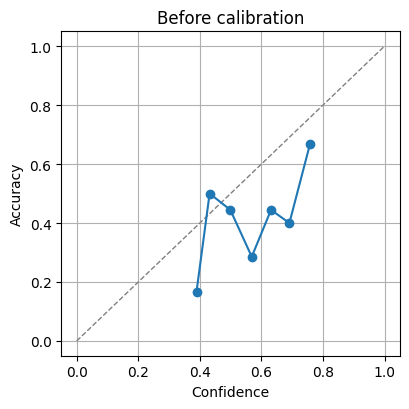

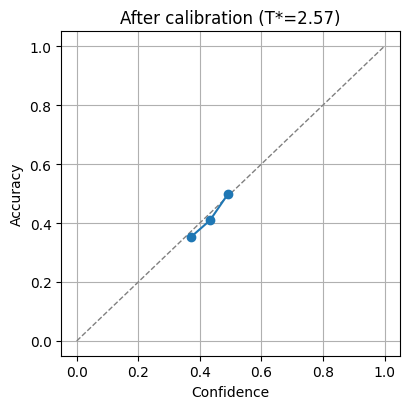

In [ ]:
import matplotlib.pyplot as plt, numpy as np

def reliability_diagram(probs, labels, n_bins=15, title="Reliability"):
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == labels)
    bins = np.linspace(0, 1, n_bins + 1)  # ensure n_bins is int
    xs, accs, confs = [], [], []
    for i in range(n_bins):
        m = (conf > bins[i]) & (conf <= bins[i + 1])
        if m.sum() == 0:
            continue
        xs.append((bins[i] + bins[i + 1]) / 2)
        accs.append(correct[m].mean())
        confs.append(conf[m].mean())

    plt.figure(figsize=(4.2, 4.2))
    plt.plot([0, 1], [0, 1], '--', lw=1, color='gray')
    plt.plot(confs, accs, marker='o')
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()

reliability_diagram(probs_uncal, y_true, title="Before calibration")
reliability_diagram(probs_cal, y_true, title=f"After calibration (T*={T_star:.2f})")
plt.show()



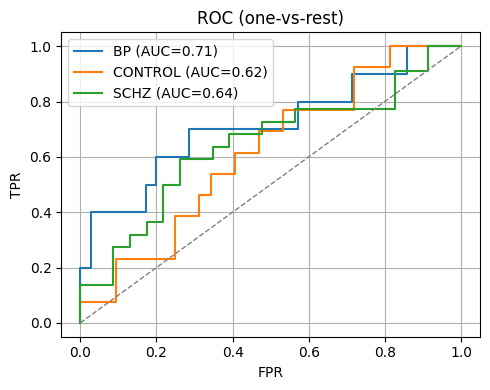

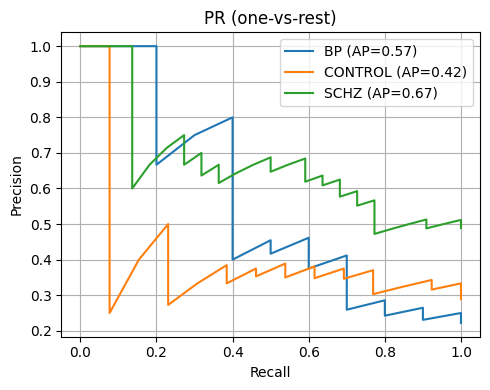

Classification report:
               precision    recall  f1-score   support

          BP       0.39      0.70      0.50        10
     CONTROL       0.36      0.69      0.47        13
        SCHZ       1.00      0.09      0.17        22

    accuracy                           0.40        45
   macro avg       0.58      0.49      0.38        45
weighted avg       0.68      0.40      0.33        45



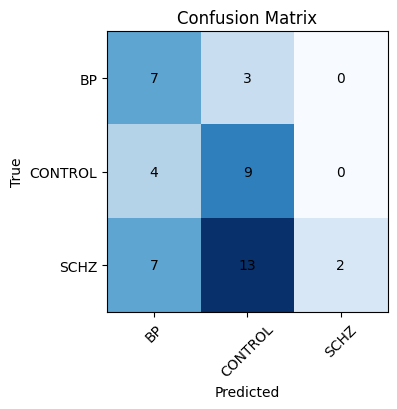

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, classification_report, average_precision_score, roc_auc_score

y_bin = np.eye(len(cls_names))[y_true]
plt.figure(figsize=(5,4))
for c,name in enumerate(cls_names):
    fpr, tpr, _ = roc_curve(y_bin[:,c], probs_cal[:,c])
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_bin[:,c], probs_cal[:,c]):.2f})")
plt.plot([0,1],[0,1],'--',lw=1,color='gray'); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC (one-vs-rest)"); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# PR
plt.figure(figsize=(5,4))
for c,name in enumerate(cls_names):
    pr, rc, _ = precision_recall_curve(y_bin[:,c], probs_cal[:,c])
    plt.plot(rc, pr, label=f"{name} (AP={average_precision_score(y_bin[:,c], probs_cal[:,c]):.2f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR (one-vs-rest)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

y_hat = probs_cal.argmax(axis=1)
cm = confusion_matrix(y_true, y_hat)
print("Classification report:\n", classification_report(y_true, y_hat, target_names=cls_names))

plt.figure(figsize=(4.2,4.2))
plt.imshow(cm, cmap='Blues'); plt.title("Confusion Matrix")
plt.xticks(range(len(cls_names)), cls_names, rotation=45); plt.yticks(range(len(cls_names)), cls_names)
for i in range(len(cls_names)):
    for j in range(len(cls_names)):
        plt.text(j,i,cm[i,j],ha='center',va='center')
plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()


In [40]:
from sklearn.metrics import roc_auc_score, average_precision_score
ix_control = cls_names.index('CONTROL')
ix_disease = [i for i,c in enumerate(cls_names) if i != ix_control]
y_binary = (np.array(y_true) != ix_control).astype(int)      # 1 = disease
p_binary = probs_cal[:, ix_disease].sum(axis=1)               # P(disease)
print({"AUC_disease_vs_control": roc_auc_score(y_binary, p_binary),
       "AP_binary": average_precision_score(y_binary, p_binary)})


{'AUC_disease_vs_control': 0.6153846153846154, 'AP_binary': 0.8212099615786397}


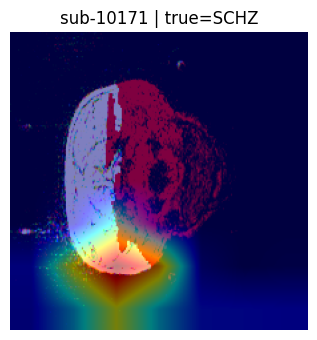

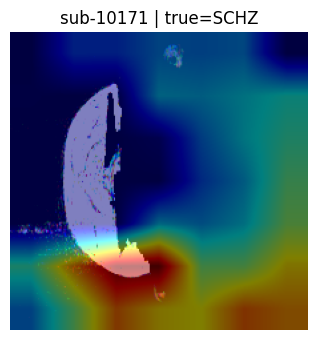

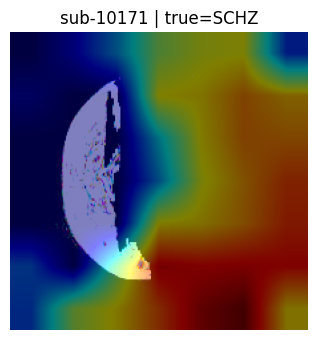

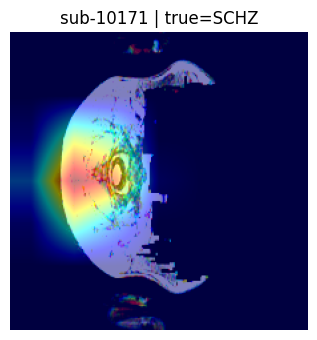

In [ ]:
import torch, numpy as np, matplotlib.pyplot as plt
import torch.nn as nn
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
final_model = final_model.to(device).eval()

candidates = []
try:    candidates.append(final_model.cnn.features[-1][0])
except: pass
try:    candidates.append(final_model.cnn.features[-1])
except: pass
try:    candidates.append(final_model.cnn.features[6][0])
except: pass
target_layer = [c for c in candidates if c is not None][0]

class ModelWithFixedTab(nn.Module):
    def __init__(self, model, tab_batch):
        super().__init__()
        self.model = model
        self.tab_batch = tab_batch
    def forward(self, x):
        return self.model(x, self.tab_batch)

x, y, sid, tab = next(iter(val_loader))
x   = x.to(device)
tab = tab.to(device)

wrapped = ModelWithFixedTab(final_model, tab)

with GradCAM(model=wrapped, target_layers=[target_layer]) as cam:
    maps = cam(
        input_tensor=x,
        targets=[ClassifierOutputTarget(int(t)) for t in y],
        eigen_smooth=True   # optional smoothing
    )

imgs = x.detach().cpu().numpy().transpose(0,2,3,1)
for i in range(min(4, len(imgs))):
    base = (imgs[i]*0.5+0.5).clip(0,1)  # unnormalize from [-1,1] back to [0,1]
    vis  = show_cam_on_image(base, maps[i], use_rgb=True)
    plt.figure(figsize=(3.5,3.5))
    plt.title(f"{sid[i]} | true={cls_names[int(y[i])]}")
    plt.imshow(vis); plt.axis("off"); plt.tight_layout(); plt.show()


In [49]:
import numpy as np
from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef, roc_auc_score

rng = np.random.default_rng(123)
B = 1000

def boot_ci(stat_fn):
    idx = np.arange(len(y_true))
    vals = []
    for _ in range(B):
        b = rng.choice(idx, size=len(idx), replace=True)
        vals.append(stat_fn(b))
    vals = np.array(vals)
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

y_bin_ovr = np.eye(len(cls_names))[y_true]  # for macro AUC

def stat_macro_auc(b):
    aucs = [roc_auc_score(y_bin_ovr[b][:,c], probs_cal[b][:,c]) for c in range(len(cls_names))]
    return np.mean(aucs)

def stat_bacc(b): return balanced_accuracy_score(y_true[b], probs_cal[b].argmax(1))
def stat_mcc(b):  return matthews_corrcoef(y_true[b], probs_cal[b].argmax(1))
def stat_ece(b):  return expected_calibration_error(probs_cal[b], y_true[b])

print("95% CI (macro AUC):", boot_ci(stat_macro_auc))
print("95% CI (BAcc):     ", boot_ci(stat_bacc))
print("95% CI (MCC):      ", boot_ci(stat_mcc))
print("95% CI (ECE):      ", boot_ci(stat_ece))


95% CI (macro AUC): (0.5272437830687831, 0.7836171895588802)
95% CI (BAcc):      (0.36213888888888895, 0.6280385375494071)
95% CI (MCC):       (0.029366244107067136, 0.41295066492743066)
95% CI (ECE):       (0.02709082346823479, 0.19942563088403803)


In [50]:
from sklearn.utils import shuffle
from sklearn.metrics import roc_auc_score

def macro_auc_from(probs, y):
    yb = np.eye(len(cls_names))[y]
    aucs = [roc_auc_score(yb[:,c], probs[:,c]) for c in range(len(cls_names))]
    return float(np.mean(aucs))

obs = macro_auc_from(probs_cal, y_true)
P = 200
cnt = 0
for seed in range(P):
    y_perm = shuffle(y_true, random_state=seed)
    if macro_auc_from(probs_cal, y_perm) >= obs:
        cnt += 1
pval = (cnt+1)/(P+1)
print({"macro_auc_obs": obs, "perm_p_value": pval})


{'macro_auc_obs': 0.6579797014579624, 'perm_p_value': 0.014925373134328358}


In [51]:
from sklearn.metrics import roc_curve
ops = {}
for i,c in enumerate(cls_names):
    y_c = (y_true == i).astype(int)
    fpr,tpr,thr = roc_curve(y_c, probs_cal[:,i])
    j = np.argmax(tpr - fpr)  # Youden's J statistic
    ops[c] = {"thr": float(thr[j]), "sens": float(tpr[j]), "spec": float(1-fpr[j])}
ops


{'BP': {'thr': 0.35574057698249817, 'sens': 0.7, 'spec': 0.7142857142857143},
 'CONTROL': {'thr': 0.358952134847641,
  'sens': 0.7692307692307693,
  'spec': 0.46875},
 'SCHZ': {'thr': 0.29112640023231506,
  'sens': 0.5909090909090909,
  'spec': 0.7391304347826086}}

In [52]:
import torch.nn as nn, torchvision
from torchvision.models import efficientnet_b0

class ImageOnlyEffNet(nn.Module):
    def __init__(self, n_classes, drop=0.3, pretrained=True):
        super().__init__()
        self.cnn = efficientnet_b0(weights=(torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None))
        in_f = self.cnn.classifier[1].in_features
        self.cnn.classifier[1] = nn.Identity()
        self.head = nn.Sequential(nn.Dropout(drop), nn.Linear(in_f,256), nn.ReLU(),
                                  nn.Dropout(drop), nn.Linear(256,n_classes))
    def forward(self, x_img, _tab):  # ignore tabular
        return self.head(self.cnn(x_img))

img_only = ImageOnlyEffNet(n_classes=len(cls_names), drop=0.3, pretrained=True)
img_only = train_strong(img_only, train_loader, val_loader, epochs=5, lr=5e-4, wd=1e-5, freeze_epochs=2)
metrics_img, _, _ = evaluate_model(img_only, val_loader, len(cls_names))
print("Ablation — Image-only:", metrics_img)
print("Ablation — Fusion (final):", {"macro_auc": float(macro_auc), "macro_pr": float(macro_pr),
                                     "mcc": float(mcc), "bacc": float(bacc), "ece": float(ece_cal)})


Epoch 01 | AUC=0.558 | PR=0.478 | MCC=0.000 | BAcc=0.333
Epoch 02 | AUC=0.583 | PR=0.482 | MCC=-0.016 | BAcc=0.321
Epoch 03 | AUC=0.595 | PR=0.444 | MCC=0.000 | BAcc=0.333
Epoch 04 | AUC=0.642 | PR=0.479 | MCC=0.126 | BAcc=0.423
Epoch 05 | AUC=0.665 | PR=0.513 | MCC=0.217 | BAcc=0.494
Ablation — Image-only: {'macro_auc': 0.6650882993817776, 'macro_pr': 0.5133317686403798, 'mcc': 0.2173153603821905, 'bacc': 0.49440559440559434, 'ece': 0.15007959471808544}
Ablation — Fusion (final): {'macro_auc': 0.6579797014579624, 'macro_pr': 0.5543984439229781, 'mcc': 0.22351133832766754, 'bacc': 0.49440559440559434, 'ece': 0.01967218452029756}


In [55]:

reliability_diagram(probs_uncal, y_true, title="Before calibration")
save_current("reliability_before.png"); plt.close()

reliability_diagram(probs_cal,  y_true, title=f"After calibration (T*={T_star:.2f})")
save_current("reliability_after.png"); plt.close()

print("Saved figures to:", FIG_DIR)


Saved figures to: ./outputs/figs


In [ ]:
import os, re, numpy as np, pandas as pd

# Make sure we have parts (from your earlier audit). If not, reload:
if 'parts' not in globals():
    parts = pd.read_csv(os.path.join(DATA_ROOT, "participants.tsv"), sep="\t")
    parts = parts.rename(columns={"diagnosis":"diagnosis_final"})
parts["diagnosis_final"] = parts["diagnosis_final"].astype(str).str.upper()
parts["participant_id"] = parts["participant_id"].astype(str)

want = [
    "adhd.tsv","barratt.tsv","ant.tsv","wais.tsv","stroop.tsv",
    "chapper.tsv","chaphyp.tsv","chapsoc.tsv","cpt.tsv","tci.tsv",
    "wms.tsv","dkefs.tsv","hopkins.tsv","discounting.tsv"
]

ph = None
ph_dir = os.path.join(DATA_ROOT, "phenotype")
available = [f for f in want if os.path.exists(os.path.join(ph_dir,f))]
for fn in available:
    t = pd.read_csv(os.path.join(ph_dir, fn), sep="\t")
    if "participant_id" not in t.columns: 
        # try to locate an id-like column
        for c in t.columns:
            if re.search(r"(subject|participant).*id", c, re.I):
                t = t.rename(columns={c:"participant_id"})
                break
    if "participant_id" in t.columns:
        t["participant_id"] = t["participant_id"].astype(str)
        ph = t if ph is None else ph.merge(t, on="participant_id", how="outer")

print("Phenotype files merged:", len(available), "-> shape", None if ph is None else ph.shape)

# Join labels and restrict to ADHD/CONTROL
dat = parts[["participant_id","diagnosis_final"]].merge(ph, on="participant_id", how="left")
dat = dat[dat["diagnosis_final"].isin(["ADHD","CONTROL"])].copy()
y = (dat["diagnosis_final"]=="ADHD").astype(int).values

X = dat.drop(columns=["participant_id","diagnosis_final"]).select_dtypes(include=[np.number]).copy()


for c in X.columns:
    if np.isfinite(X[c]).sum() and X[c].nunique(dropna=True)==1:
        # drop true constants
        X.drop(columns=[c], inplace=True)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())  # median impute
print("Final ADHD dataset:", X.shape, "positives(ADHD)=", int(y.sum()), "controls=", int((1-y).sum()))


Phenotype files merged: 14 -> shape (272, 657)
Final ADHD dataset: (173, 588) positives(ADHD)= 43 controls= 130


In [ ]:
import numpy as np

all_nan_cols = X.columns[X.isna().all()]
if len(all_nan_cols):
    X = X.drop(columns=all_nan_cols)
    print(f"Dropped all-NaN columns: {len(all_nan_cols)}")

const_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
if len(const_cols):
    X = X.drop(columns=const_cols)
    print(f"Dropped constant columns: {len(const_cols)}")

X = X.replace([np.inf, -np.inf], np.nan)

print("After cleanup -> shape:", X.shape, "| total NaNs:", int(X.isna().sum().sum()))


After cleanup -> shape: (173, 585) | total NaNs: 1315


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score, matthews_corrcoef
import warnings
warnings.filterwarnings("ignore")

# Optuna install/import
try:
    import optuna
except ImportError:
    !pip install -q optuna
    import optuna

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [ ]:


X_np = X.to_numpy() if hasattr(X, "to_numpy") else np.asarray(X)
y_np = y.to_numpy().ravel() if hasattr(y, "to_numpy") else np.asarray(y).ravel()

print("X_np:", X_np.shape, " y_np:", y_np.shape, " classes:", np.unique(y_np))

reuse_existing_split = False
try:
    X_train, X_test, y_train, y_test  # noqa
    # If they exist, convert them to NumPy (in case they are DataFrames/Series)
    X_train = X_train.to_numpy() if hasattr(X_train, "to_numpy") else np.asarray(X_train)
    X_test  = X_test.to_numpy()  if hasattr(X_test, "to_numpy")  else np.asarray(X_test)
    y_train = y_train.to_numpy().ravel() if hasattr(y_train, "to_numpy") else np.asarray(y_train).ravel()
    y_test  = y_test.to_numpy().ravel()  if hasattr(y_test, "to_numpy")  else np.asarray(y_test).ravel()
    reuse_existing_split = True
    print("[INFO] Reusing existing train/test split:",
          "train", X_train.shape, "test", X_test.shape)
except NameError:
    pass

if not reuse_existing_split:
    X_train, X_test, y_train, y_test = train_test_split(
        X_np, y_np, test_size=0.2, stratify=y_np, random_state=RANDOM_STATE
    )
    print("[INFO] Created new train/test split:",
          "train", X_train.shape, "test", X_test.shape)

n_classes = len(np.unique(y_train))


X_np: (173, 585)  y_np: (173,)  classes: [0 1]
[INFO] Created new train/test split: train (138, 585) test (35, 585)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

def cv_roc_auc(y_true, proba):
    if len(np.unique(y_true)) == 2:
        return roc_auc_score(y_true, proba[:, 1])
    else:
        return roc_auc_score(y_true, proba, multi_class='ovr', average='macro')

def objective(trial):
    C     = trial.suggest_float('svc_C',     1e-4, 10.0, log=True)
    gamma = trial.suggest_float('svc_gamma', 1e-4, 10.0, log=True)

    pipe = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('svc', SVC(kernel='rbf',
                    C=C, gamma=gamma,
                    probability=True,
                    class_weight='balanced',
                    random_state=RANDOM_STATE))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr, va in cv.split(X_train, y_train):
        pipe.fit(X_train[tr], y_train[tr])
        proba = pipe.predict_proba(X_train[va])
        scores.append(cv_roc_auc(y_train[va], proba))
    return float(np.mean(scores))



In [ ]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=50, show_progress_bar=False)

best_params = study.best_params
best_score  = study.best_value
print("Best params:", best_params)
print("5-fold CV ROC-AUC (train):", round(best_score, 4))


[I 2025-10-23 19:39:20,652] A new study created in memory with name: no-name-7d4ebfe1-c805-478b-9f43-d1070e29be5f
[I 2025-10-23 19:39:20,730] Trial 0 finished with value: 0.5 and parameters: {'svc_C': 0.0074593432857265485, 'svc_gamma': 5.669849511478849}. Best is trial 0 with value: 0.5.
[I 2025-10-23 19:39:20,790] Trial 1 finished with value: 0.5 and parameters: {'svc_C': 0.45705630998014507, 'svc_gamma': 0.09846738873614563}. Best is trial 0 with value: 0.5.
[I 2025-10-23 19:39:20,838] Trial 2 finished with value: 0.08115646258503403 and parameters: {'svc_C': 0.0006026889128682511, 'svc_gamma': 0.000602521573620386}. Best is trial 0 with value: 0.5.
[I 2025-10-23 19:39:20,884] Trial 3 finished with value: 0.5 and parameters: {'svc_C': 0.00019517224641449495, 'svc_gamma': 2.142302175774105}. Best is trial 0 with value: 0.5.
[I 2025-10-23 19:39:20,932] Trial 4 finished with value: 0.5 and parameters: {'svc_C': 0.10129197956845731, 'svc_gamma': 0.34702669886504117}. Best is trial 0 wit

Best params: {'svc_C': 0.211005476020198, 'svc_gamma': 0.0016665942530435956}
5-fold CV ROC-AUC (train): 0.9279


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

final_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler()),
    ('svc', SVC(kernel='rbf',
                C=best_params['svc_C'],
                gamma=best_params['svc_gamma'],
                probability=True,
                class_weight='balanced',
                random_state=RANDOM_STATE))
])

final_pipe.fit(X_train, y_train)

proba_test = final_pipe.predict_proba(X_test)
pred_test  = final_pipe.predict(X_test)

if n_classes == 2:
    auc = roc_auc_score(y_test, proba_test[:, 1])
else:
    auc = roc_auc_score(y_test, proba_test, multi_class='ovr', average='macro')

bal_acc = balanced_accuracy_score(y_test, pred_test)
mcc     = matthews_corrcoef(y_test, pred_test)
f1m     = f1_score(y_test, pred_test, average='macro')

print(f"Test ROC-AUC:           {auc:.4f}")
print(f"Test Balanced Accuracy: {bal_acc:.4f}")
print(f"Test MCC:               {mcc:.4f}")
print(f"Test F1 (macro):        {f1m:.4f}")


Test ROC-AUC:           0.9573
Test Balanced Accuracy: 0.8846
Test MCC:               0.6794
Test F1 (macro):        0.8098


AUC uncalibrated: 0.9573
AUC calibrated  : 0.9573
Brier uncalibrated: 0.1597
Brier calibrated  : 0.0943


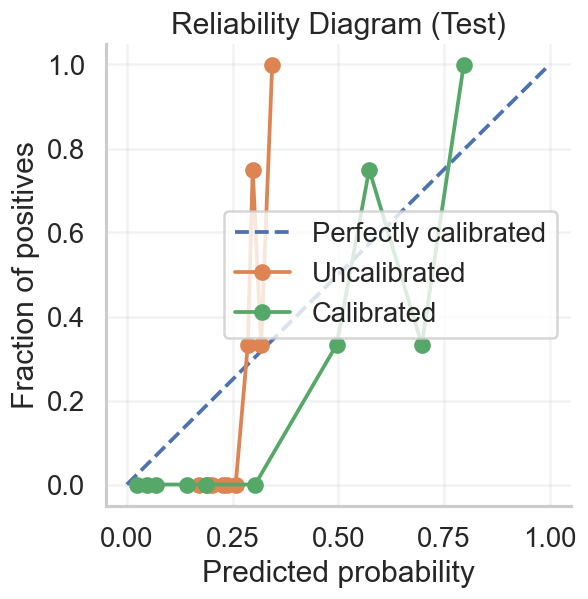

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import numpy as np

X_tr_sub, X_val_sub, y_tr_sub, y_val_sub = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

base_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler()),
    ('svc', SVC(kernel='rbf',
                C=best_params['svc_C'],
                gamma=best_params['svc_gamma'],
                probability=True,
                class_weight='balanced',
                random_state=RANDOM_STATE))
])

base_pipe.fit(X_tr_sub, y_tr_sub)

calibrated = CalibratedClassifierCV(base_pipe, method='sigmoid', cv='prefit')
calibrated.fit(X_val_sub, y_val_sub)

proba_uncal = base_pipe.predict_proba(X_test)[:,1]
proba_cal   = calibrated.predict_proba(X_test)[:,1]

auc_uncal = roc_auc_score(y_test, proba_uncal)
auc_cal   = roc_auc_score(y_test, proba_cal)

brier_uncal = brier_score_loss(y_test, proba_uncal)
brier_cal   = brier_score_loss(y_test, proba_cal)

print(f"AUC uncalibrated: {auc_uncal:.4f}")
print(f"AUC calibrated  : {auc_cal:.4f}")
print(f"Brier uncalibrated: {brier_uncal:.4f}")
print(f"Brier calibrated  : {brier_cal:.4f}")

prob_true_u, prob_pred_u = calibration_curve(y_test, proba_uncal, n_bins=10, strategy='quantile')
prob_true_c, prob_pred_c = calibration_curve(y_test, proba_cal,   n_bins=10, strategy='quantile')

plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1], linestyle='--', label='Perfectly calibrated')
plt.plot(prob_pred_u, prob_true_u, marker='o', label='Uncalibrated')
plt.plot(prob_pred_c, prob_true_c, marker='o', label='Calibrated')
plt.xlabel('Predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Reliability Diagram (Test)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve


val_scores = calibrated.predict_proba(X_val_sub)[:,1]
fpr, tpr, thr = roc_curve(y_val_sub, val_scores)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_thr = thr[best_idx]
print(f"Chosen threshold (Youden’s J on val): {best_thr:.4f}")

test_scores = calibrated.predict_proba(X_test)[:,1]
test_pred_thr = (test_scores >= best_thr).astype(int)

cm = confusion_matrix(y_test, test_pred_thr)
print("Confusion matrix (Test, thresholded):")
print(cm)
print("\nClassification report (Test, thresholded):")
print(classification_report(y_test, test_pred_thr, digits=4))


Chosen threshold (Youden’s J on val): 0.5561
Confusion matrix (Test, thresholded):
[[24  2]
 [ 2  7]]

Classification report (Test, thresholded):
              precision    recall  f1-score   support

           0     0.9231    0.9231    0.9231        26
           1     0.7778    0.7778    0.7778         9

    accuracy                         0.8857        35
   macro avg     0.8504    0.8504    0.8504        35
weighted avg     0.8857    0.8857    0.8857        35



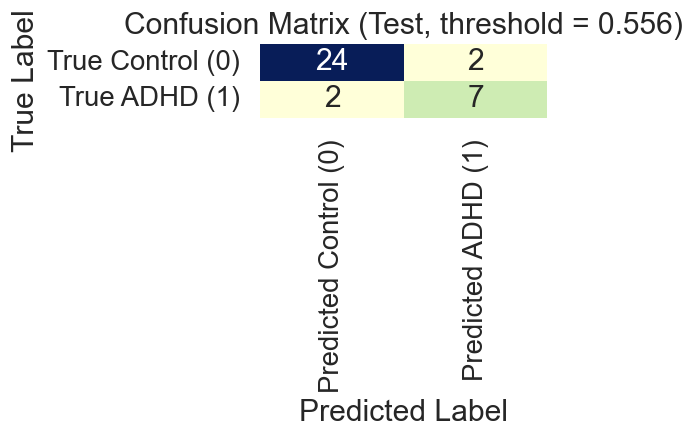

AUC (test): 0.9573
Balanced Accuracy: 0.8846
MCC: 0.6794
F1 (macro): 0.8098


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_pred_thr)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="YlGnBu",
            cbar=False,
            xticklabels=["Predicted Control (0)", "Predicted ADHD (1)"],
            yticklabels=["True Control (0)", "True ADHD (1)"])
plt.title("Confusion Matrix (Test, threshold = {:.3f})".format(best_thr))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print(f"AUC (test): {auc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"F1 (macro): {f1m:.4f}")


{'CV_AUC_mean': 0.922, 'CV_AUC_sd': 0.065, 'CV_AP_mean': 0.88, 'CV_AP_sd': 0.091}
{'CV_AUC_95CI': [0.857, 0.967], 'CV_AP_95CI': [0.787, 0.94]}


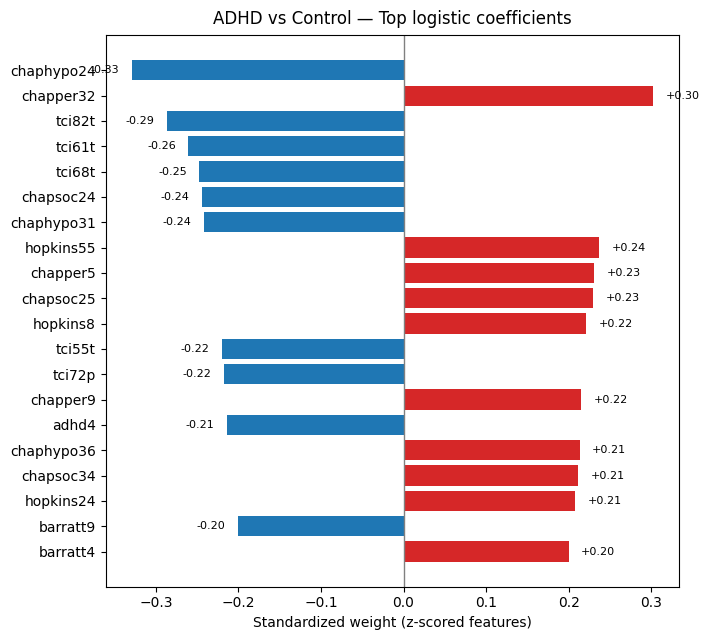

Saved: OUT/phenotype_adhd/adhd_vs_control_top_coeffs.png and OUT/phenotype_adhd/adhd_vs_control_coeffs.csv

Top 20 features:
   feature      coef
chaphypo24 -0.329283
 chapper32  0.302447
    tci82t -0.286943
    tci61t -0.260572
    tci68t -0.247457
 chapsoc24 -0.244058
chaphypo31 -0.241682
 hopkins55  0.237279
  chapper5  0.231182
 chapsoc25  0.229859
  hopkins8  0.221116
    tci55t -0.220217
    tci72p -0.217651
  chapper9  0.215319
     adhd4 -0.214194
chaphypo36  0.213590
 chapsoc34  0.211900
 hopkins24  0.207798
  barratt9 -0.200860
  barratt4  0.200253


In [ ]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.utils import resample


assert set(np.unique(y)).issubset({0,1}), "y must be binary: 0=CONTROL, 1=ADHD"

Xc = X.copy().replace([np.inf, -np.inf], np.nan)
drop_cols = [c for c in Xc.columns if Xc[c].nunique(dropna=True) <= 1]
if drop_cols:
    print(f"Dropping {len(drop_cols)} near-constant/empty columns.")
    Xc = Xc.drop(columns=drop_cols)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs, aps = [], []

base_pipe = Pipeline([
    ("imp",    SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
    ("clf",    LogisticRegression(
                 max_iter=4000, class_weight="balanced",
                 penalty="l2", solver="liblinear", C=1.0))
])

for tr, va in skf.split(Xc, y):
    base_pipe.fit(Xc.iloc[tr], y[tr])
    p = base_pipe.predict_proba(Xc.iloc[va])[:,1]
    aucs.append(roc_auc_score(y[va], p))
    aps.append(average_precision_score(y[va], p))

auc_mean, auc_sd = float(np.mean(aucs)), float(np.std(aucs))
ap_mean, ap_sd   = float(np.mean(aps)),  float(np.std(aps))
print({"CV_AUC_mean": round(auc_mean,3), "CV_AUC_sd": round(auc_sd,3),
       "CV_AP_mean":  round(ap_mean,3),  "CV_AP_sd":  round(ap_sd,3)})


rng = np.random.default_rng(123)
B = 1000

def boot_ci(vals):
    vals = np.asarray(vals)
    idx = np.arange(len(vals))
    boots = []
    for _ in range(B):
        b = rng.choice(idx, size=len(idx), replace=True)
        boots.append(np.mean(vals[b]))
    return float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))

auc_ci = boot_ci(aucs)
ap_ci  = boot_ci(aps)
print({"CV_AUC_95CI": [round(auc_ci[0],3), round(auc_ci[1],3)],
       "CV_AP_95CI":  [round(ap_ci[0],3),  round(ap_ci[1],3)]})


final_pipe = Pipeline([
    ("imp",    SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
    ("clf",    LogisticRegression(
                 max_iter=4000, class_weight="balanced",
                 penalty="l2", solver="liblinear", C=1.0))
]).fit(Xc, y)

coef = final_pipe.named_steps["clf"].coef_[0]
coef_df = pd.DataFrame({"feature": Xc.columns, "coef": coef, "abs_coef": np.abs(coef)})
coef_top = coef_df.sort_values("abs_coef", ascending=False).head(20).reset_index(drop=True)


colors = ["#d62728" if c>0 else "#1f77b4" for c in coef_top["coef"]]
plt.figure(figsize=(7.2,6.5))
plt.barh(coef_top["feature"][::-1], coef_top["coef"][::-1], color=colors[::-1])
for i, v in enumerate(coef_top["coef"][::-1]):
    plt.text(v + (0.015*np.sign(v)), i, f"{v:+.2f}", va="center",
             ha="left" if v>0 else "right", fontsize=8)
plt.axvline(0, color="gray", lw=1)
plt.title("ADHD vs Control — Top logistic coefficients", pad=8)
plt.xlabel("Standardized weight (z-scored features)")
plt.tight_layout()


OUT_DIR = os.path.join("OUT", "phenotype_adhd")
os.makedirs(OUT_DIR, exist_ok=True)
fig_path = os.path.join(OUT_DIR, "adhd_vs_control_top_coeffs.png")
csv_path = os.path.join(OUT_DIR, "adhd_vs_control_coeffs.csv")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

coef_df.sort_values("abs_coef", ascending=False).to_csv(csv_path, index=False)
print("Saved:", fig_path, "and", csv_path)

print("\nTop 20 features:")
print(coef_top[["feature","coef"]].to_string(index=False))


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe_full = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),    
    ("scaler", StandardScaler()),                     
    ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
]).fit(X, y)

p_full = pipe_full.predict_proba(X)[:, 1]


In [ ]:
import numpy as np

Xt = pipe_full.named_steps["imputer"].transform(X)
print("NaNs left after imputation:", np.isnan(Xt).sum())


NaNs left after imputation: 0


In [70]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
import numpy as np

def oof_probas_np(pipe, X, y, n_splits=5, random_state=42):
    Xn = X.values if hasattr(X, "values") else np.asarray(X)
    yn = y.values if hasattr(y, "values") else np.asarray(y)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    p = np.empty(len(yn), dtype=float)

    for tr, va in skf.split(Xn, yn):
        m = clone(pipe)
        m.fit(Xn[tr], yn[tr])
        p[va] = m.predict_proba(Xn[va])[:, 1]

    return p

p_full = oof_probas_np(pipe_full, X, y)



In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, average_precision_score

Xn = X.values if hasattr(X, "values") else np.asarray(X)
yn = y.values if hasattr(y, "values") else np.asarray(y)


pipe_full = Pipeline([
    ("imp_med", SimpleImputer(strategy="median")),
    ("imp_const", SimpleImputer(strategy="constant", fill_value=0.0)),
    ("scaler", StandardScaler(with_mean=True)),
    ("clf", LogisticRegression(max_iter=4000, class_weight="balanced", solver="lbfgs"))
])

def oof_probas_np(pipe, Xn, yn, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    p = np.empty(len(yn), dtype=float)
    for tr, va in skf.split(Xn, yn):
        m = clone(pipe)
        m.fit(Xn[tr], yn[tr])
        p[va] = m.predict_proba(Xn[va])[:, 1]
    return p

p_full = oof_probas_np(pipe_full, Xn, yn, n_splits=5, random_state=42)

rng = np.random.default_rng(123)
B = 1000
classes = np.unique(yn)
idx_by_c = {c: np.where(yn == c)[0] for c in classes}
counts = {c: (yn == c).sum() for c in classes}

def strat_boot(stat_fn):
    vals = []
    for _ in range(B):
        b_parts = [rng.choice(idx_by_c[c], size=counts[c], replace=True) for c in classes]
        b = np.concatenate(b_parts)
        rng.shuffle(b)
        vals.append(stat_fn(b))
    vals = np.asarray(vals, float)
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

auc_ci = strat_boot(lambda b: roc_auc_score(yn[b], p_full[b]))
ap_ci  = strat_boot(lambda b: average_precision_score(yn[b], p_full[b]))
print({"AUC_CI95": auc_ci, "AP_CI95": ap_ci})


{'AUC_CI95': (0.8643828264758497, 0.9524239713774597), 'AP_CI95': (0.7139476219745587, 0.892358477647708)}


In [74]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [75]:
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", context="talk")


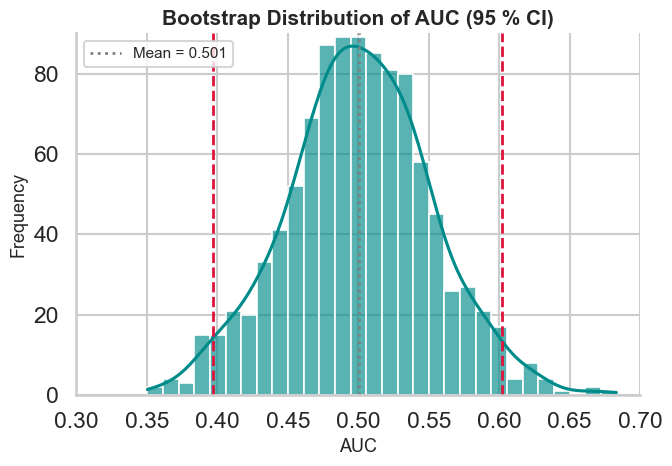

In [79]:
import seaborn as sns, matplotlib.pyplot as plt, numpy as np
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid", context="talk", palette="deep")

rng = np.random.default_rng(123)
boot_aucs = [roc_auc_score(
    yn[rng.choice(len(yn), len(yn), True)],
    p_full[rng.choice(len(yn), len(yn), True)]
) for _ in range(1000)]

low, high = np.percentile(boot_aucs, [2.5, 97.5])

plt.figure(figsize=(7,5))
sns.histplot(boot_aucs, bins=30, kde=True, color="#008B8B", alpha=0.65)
plt.axvline(low,  color="crimson", linestyle="--", lw=2)
plt.axvline(high, color="crimson", linestyle="--", lw=2)
plt.axvline(np.mean(boot_aucs), color="gray", linestyle=":", lw=2, label=f"Mean = {np.mean(boot_aucs):.3f}")
plt.xlim(0.3, 0.7)
plt.ylim(0, 90)
plt.title("Bootstrap Distribution of AUC (95 % CI)", fontsize=15, weight="bold")
plt.xlabel("AUC", fontsize=13)
plt.ylabel("Frequency", fontsize=13)
plt.legend(frameon=True, loc="upper left", fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig("bootstrap_auc_ci_final.png", dpi=300, bbox_inches="tight")
plt.show()



In [ ]:
from sklearn.utils import shuffle

obs_auc = roc_auc_score(y, p_full)
P = 500
cnt = 0
for seed in range(P):
    if roc_auc_score(shuffle(y, random_state=seed), p_full) >= obs_auc:
        cnt += 1
pval = (cnt+1)/(P+1)
print({"AUC_observed": float(obs_auc), "perm_p_value": float(pval)})


{'AUC_observed': 0.9144901610017889, 'perm_p_value': 0.001996007984031936}


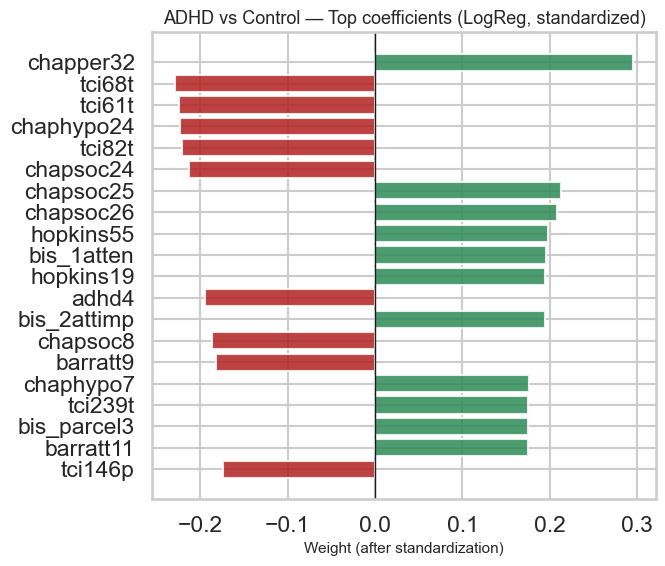

Top 20 features (standardized weights):
    feature  coef_std
  chapper32  0.295133
     tci68t -0.228663
     tci61t -0.224588
 chaphypo24 -0.223142
     tci82t -0.220106
  chapsoc24 -0.212677
  chapsoc25  0.212420
  chapsoc26  0.207961
  hopkins55  0.198273
 bis_1atten  0.195543
  hopkins19  0.194553
      adhd4 -0.193961
bis_2attimp  0.193859
   chapsoc8 -0.186077
   barratt9 -0.182017
  chaphypo7  0.176541
    tci239t  0.174985
bis_parcel3  0.174798
  barratt11  0.174404
    tci146p -0.173504


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# --- Robust pipeline: impute -> scale -> LogReg ---
pipe_full = Pipeline([
    ("imp_med",   SimpleImputer(strategy="median")),                 # fix ordinary NaNs
    ("imp_const", SimpleImputer(strategy="constant", fill_value=0)), # safety for all-NaN cols
    ("scaler",    StandardScaler(with_mean=True)),
    ("clf",       LogisticRegression(max_iter=4000, class_weight="balanced", solver="lbfgs"))
]).fit(X, y)


coef_std = pipe_full.named_steps["clf"].coef_.ravel()
feat     = np.asarray(X.columns)


scale = pipe_full.named_steps["scaler"].scale_
scale_safe = np.where(scale == 0, np.inf, scale)
coef_orig = coef_std / scale_safe

use = "std" 
coef_for_ranking = coef_std if use == "std" else coef_orig

imp = pd.DataFrame({
    "feature": feat,
    "coef_std": coef_std,
    "coef_orig": coef_orig,
    "abs_coef": np.abs(coef_for_ranking)
}).sort_values("abs_coef", ascending=False)

topk = 20
top = imp.head(topk)

plt.figure(figsize=(7,6))

vals = top["coef_std"].to_numpy()[::-1]
labels = top["feature"].to_numpy()[::-1]
colors = np.where(vals >= 0, "#2E8B57", "#B22222")  

plt.barh(labels, vals, color=colors, alpha=0.85)
plt.axvline(0, color="k", lw=1)
plt.title("ADHD vs Control — Top coefficients (LogReg, standardized)", fontsize=13)
plt.xlabel("Weight (after standardization)", fontsize=11)
plt.tight_layout()
plt.show()

print("Top 20 features (standardized weights):")
print(top[["feature", "coef_std"]].to_string(index=False))



In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from numpy.random import default_rng

RANDOM_STATE = 42
rng = default_rng(RANDOM_STATE)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [ ]:

SUBJECT_COL = None 

if SUBJECT_COL is not None and SUBJECT_COL in locals() and SUBJECT_COL in X.columns:
    groups = X[SUBJECT_COL].astype(str).to_numpy()
elif SUBJECT_COL is not None and SUBJECT_COL in globals():
    
    groups = labels[SUBJECT_COL].astype(str).to_numpy()
else:
   
    groups = np.arange(len(y))


In [85]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.base import clone

def group_oof_probas(pipe, X, y, groups, n_splits=5, random_state=RANDOM_STATE):
    Xn = X.values if hasattr(X, "values") else np.asarray(X)
    yn = y.values if hasattr(y, "values") else np.asarray(y)
    g  = groups
    
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    p = np.empty(len(yn), dtype=float)
    for tr, va in cv.split(Xn, yn, groups=g):
        m = clone(pipe)
        m.fit(Xn[tr], yn[tr])
        p[va] = m.predict_proba(Xn[va])[:, 1]
    return p


In [86]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

def stratified_bootstrap_ci(y_true, y_score, B=1000, random_state=RANDOM_STATE, quantiles=(2.5, 97.5)):
    rng = default_rng(random_state)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    classes = np.unique(y_true)
    idx_by_c = {c: np.where(y_true == c)[0] for c in classes}
    counts   = {c: (y_true == c).sum() for c in classes}

    def ci_of(stat_fn):
        vals = []
        for _ in range(B):
            parts = [rng.choice(idx_by_c[c], size=counts[c], replace=True) for c in classes]
            b = np.concatenate(parts)
            rng.shuffle(b)
            vals.append(stat_fn(b))
        lo, hi = np.percentile(vals, quantiles)
        return float(lo), float(hi)
    return ci_of

def metrics_with_ci(y_true, y_score, B=1000, random_state=RANDOM_STATE):
    ci = stratified_bootstrap_ci(y_true, y_score, B=B, random_state=random_state)
    auc_ci = ci(lambda b: roc_auc_score(y_true[b], y_score[b]))
    ap_ci  = ci(lambda b: average_precision_score(y_true[b], y_score[b]))
    brier  = brier_score_loss(y_true, y_score)
    return {"AUC_CI95": auc_ci, "AP_CI95": ap_ci, "Brier": brier}


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier

def make_logreg():
    return Pipeline([
        ("imp_med",   SimpleImputer(strategy="median")),
        ("imp_const", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("scaler",    StandardScaler()),
        ("clf",       LogisticRegression(max_iter=4000, class_weight="balanced", solver="lbfgs", random_state=RANDOM_STATE)),
    ])

def make_svm_rbf():
    return Pipeline([
        ("imp_med",   SimpleImputer(strategy="median")),
        ("imp_const", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("scaler",    StandardScaler()),
        ("clf",       SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE)),
    ])

def make_hgb():
    return Pipeline([
        ("clf", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
    ])


In [88]:
models = {
    "Logistic": make_logreg(),
    "SVM-RBF":  make_svm_rbf(),
    "HGB":      make_hgb(),
}

results = []
for name, model in models.items():
    p_oof = group_oof_probas(model, X, y, groups, n_splits=5)
    res = metrics_with_ci(y, p_oof, B=1000)
    results.append({
        "Model": name,
        "AUC_low":  res["AUC_CI95"][0], "AUC_high":  res["AUC_CI95"][1],
        "AP_low":   res["AP_CI95"][0],  "AP_high":   res["AP_CI95"][1],
        "Brier":    res["Brier"]
    })

results_df = pd.DataFrame(results).sort_values("AP_high", ascending=False)
results_df


,Model,AUC_low,AUC_high,AP_low,AP_high,Brier
2,HGB,0.952589,0.990165,0.889752,0.977961,0.058472
0,Logistic,0.878350,0.958336,0.762794,0.917636,0.099779
1,SVM-RBF,0.862784,0.952686,0.726943,0.902504,0.095109


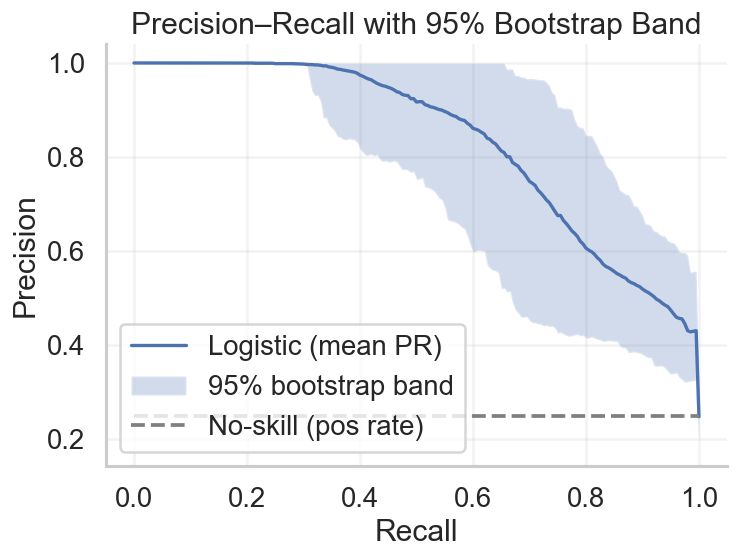

In [ ]:
from sklearn.metrics import precision_recall_curve

def pr_bootstrap_band(y_true, y_score, B=500, random_state=RANDOM_STATE, grid=np.linspace(0,1,201)):
    rng = default_rng(random_state)
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    P = []
    for _ in range(B):
        b = rng.choice(np.arange(len(y_true)), size=len(y_true), replace=True)
        pr, rc, _ = precision_recall_curve(y_true[b], y_score[b])
        P.append(np.interp(grid, rc[::-1], pr[::-1]))
    P = np.vstack(P)
    meanP = P.mean(axis=0)
    lo, hi = np.percentile(P, [2.5, 97.5], axis=0)
    return grid, meanP, lo, hi

log_p = group_oof_probas(make_logreg(), X, y, groups)
rc_grid, meanP, loP, hiP = pr_bootstrap_band(y, log_p, B=500)

plt.figure(figsize=(6.5,5))
plt.plot(rc_grid, meanP, label="Logistic (mean PR)", lw=2)
plt.fill_between(rc_grid, loP, hiP, alpha=0.25, label="95% bootstrap band")
plt.hlines(y=(y.mean()), xmin=0, xmax=1, colors="gray", linestyles="--", label="No-skill (pos rate)")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall with 95% Bootstrap Band")
plt.legend()
plt.tight_layout(); plt.show()


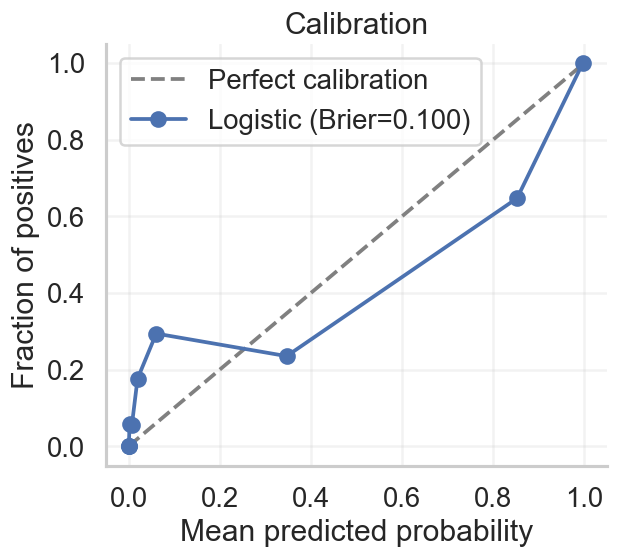

In [90]:
from sklearn.calibration import calibration_curve

def plot_calibration(y_true, y_score, n_bins=10, label="Model"):
    prob_true, prob_pred = calibration_curve(y_true, y_score, n_bins=n_bins, strategy="quantile")
    plt.figure(figsize=(5.5,5))
    plt.plot([0,1],[0,1], "--", color="gray", label="Perfect calibration")
    plt.plot(prob_pred, prob_true, marker="o", label=f"{label} (Brier={brier_score_loss(y_true, y_score):.3f})")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title("Calibration")
    plt.legend(); plt.tight_layout(); plt.show()

plot_calibration(y, log_p, label="Logistic")


In [ ]:
from sklearn.decomposition import PCA

def make_pca_logreg(n_components):
    return Pipeline([
        ("imp_med",   SimpleImputer(strategy="median")),
        ("imp_const", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("scaler",    StandardScaler()),
        ("pca",       PCA(n_components=n_components, random_state=RANDOM_STATE)),
        ("clf",       LogisticRegression(max_iter=4000, class_weight="balanced", solver="lbfgs", random_state=RANDOM_STATE)),
    ])

abl = []
for k in [4, 8, 16]:
    p = group_oof_probas(make_pca_logreg(k), X, y, groups)
    res = metrics_with_ci(y, p, B=500)  
    abl.append({"PCA_components": k,
                "AUC_low":res["AUC_CI95"][0], "AUC_high":res["AUC_CI95"][1],
                "AP_low":res["AP_CI95"][0], "AP_high":res["AP_CI95"][1]})
pd.DataFrame(abl).sort_values("AP_high", ascending=False)


,PCA_components,AUC_low,AUC_high,AP_low,AP_high
2,16,0.894070,0.967545,0.788349,0.921128
1,8,0.888081,0.961896,0.769834,0.913269
0,4,0.871351,0.956266,0.732879,0.900348


In [ ]:
import os
os.makedirs("figures", exist_ok=True)
plt.figure(figsize=(6.5,5))
plt.plot(rc_grid, meanP, lw=2, label="Logistic (mean PR)")
plt.fill_between(rc_grid, loP, hiP, alpha=0.25, label="95% bootstrap band")
plt.hlines(y=(y.mean()), xmin=0, xmax=1, colors="gray", linestyles="--", label="No-skill (pos rate)")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall with 95% Bootstrap Band")
plt.legend(); plt.tight_layout()
plt.savefig("figures/pr_band_logistic.png", dpi=300, bbox_inches="tight"); plt.close()

results_df.to_csv("figures/model_metrics_with_ci.csv", index=False)


In [93]:
!pip freeze | grep -E "sklearn|numpy|pandas|matplotlib|seaborn"


matplotlib==3.10.6
matplotlib-inline @ file:///opt/miniconda3/conda-bld/matplotlib-inline_1758520109559/work
numpy==2.2.6
pandas==2.3.3
seaborn==0.13.2


In [ ]:
# ===== Quantum Kernel SVM: Cell 1/5 =====
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, matthews_corrcoef, f1_score
from sklearn.svm import SVC

try:
    from qiskit import QuantumCircuit
    from qiskit_aer import AerSimulator
except Exception:
    !pip -q install qiskit qiskit-aer
    from qiskit import QuantumCircuit
    from qiskit_aer import AerSimulator

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

N_QUBITS = min(4, X_train.shape[1])
print("Using", N_QUBITS, "qubits")


Using 4 qubits


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

imp_q = SimpleImputer(strategy='median')
sc_q  = StandardScaler(with_mean=True, with_std=True)

X_train_qbase = imp_q.fit_transform(X_train)
X_test_qbase  = imp_q.transform(X_test)

X_train_qbase = sc_q.fit_transform(X_train_qbase)
X_test_qbase  = sc_q.transform(X_test_qbase)

print("After impute/scale ->",
      X_train_qbase.shape, X_test_qbase.shape,
      "| NaNs (train/test):",
      np.isnan(X_train_qbase).sum(), np.isnan(X_test_qbase).sum())


After impute/scale -> (138, 585) (35, 585) | NaNs (train/test): 0 0


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

pca = PCA(n_components=N_QUBITS, random_state=RANDOM_STATE)
mm  = MinMaxScaler(feature_range=(0.0, np.pi))

Xtr_pca = pca.fit_transform(X_train_qbase)
Xte_pca = pca.transform(X_test_qbase)

Xtr_q = mm.fit_transform(Xtr_pca)
Xte_q = mm.transform(Xte_pca)

assert np.isfinite(Xtr_q).all() and np.isfinite(Xte_q).all(), "Non-finite values after preprocessing!"
print("Quantum-shaped ->", Xtr_q.shape, Xte_q.shape)


Quantum-shaped -> (138, 4) (35, 4)


In [ ]:
sim = AerSimulator(method="statevector")

def feature_map_angles(x):
    """
    Simple, stable feature map:
    - Encode data with Ry on each qubit
    - Add lightweight entanglement (ring of CX)
    """
    qc = QuantumCircuit(N_QUBITS)
    for i, theta in enumerate(x):
        qc.ry(float(theta), i)
    for i in range(N_QUBITS - 1):
        qc.cx(i, i + 1)
    if N_QUBITS > 2:
        qc.cx(N_QUBITS - 1, 0)
    return qc

def statevector_from_angles(x):
    qc = feature_map_angles(x)
    qc.save_statevector()
    result = sim.run(qc, shots=0).result()
    return np.array(result.get_statevector(qc), dtype=complex)

def quantum_kernel_matrix(XA, XB):
    """
    Build kernel K[i,j] = |<psi(x_i) | psi(x'_j)>|^2  (fidelity kernel)
    """
    sv_A = [statevector_from_angles(a) for a in XA]
    sv_B = [statevector_from_angles(b) for b in XB]
    KA = np.zeros((len(sv_A), len(sv_B)))
    for i, va in enumerate(sv_A):
        va = va / np.linalg.norm(va)
        for j, vb in enumerate(sv_B):
            vb = vb / np.linalg.norm(vb)
            overlap = np.vdot(va, vb)  # <va|vb>
            KA[i, j] = float(np.abs(overlap) ** 2)
    return KA


In [ ]:

K_train = quantum_kernel_matrix(Xtr_q, Xtr_q)
K_test  = quantum_kernel_matrix(Xte_q, Xtr_q)  

qsvc = SVC(kernel='precomputed', probability=False, class_weight='balanced', random_state=RANDOM_STATE)
qsvc.fit(K_train, y_train)

dec_test = qsvc.decision_function(K_test)
from scipy.special import expit
proba_like = expit(dec_test)

auc_qk   = roc_auc_score(y_test, proba_like)
bal_qk   = balanced_accuracy_score(y_test, qsvc.predict(K_test))
mcc_qk   = matthews_corrcoef(y_test, qsvc.predict(K_test))
f1m_qk   = f1_score(y_test, qsvc.predict(K_test), average='macro')

print("[Quantum Kernel SVM]")
print(f"Test ROC-AUC:           {auc_qk:.4f}")
print(f"Test Balanced Accuracy: {bal_qk:.4f}")
print(f"Test MCC:               {mcc_qk:.4f}")
print(f"Test F1 (macro):        {f1m_qk:.4f}")


[Quantum Kernel SVM]
Test ROC-AUC:           0.9573
Test Balanced Accuracy: 0.8291
Test MCC:               0.5871
Test F1 (macro):        0.7734


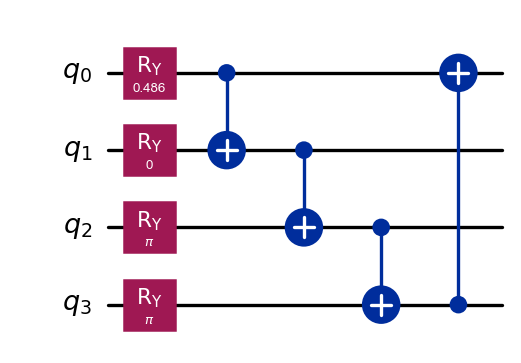

Displayed with MPL drawer.


In [ ]:

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

try:
    from qiskit.visualization import circuit_drawer
except Exception:
    !pip -q install "qiskit[visualization]"
    from qiskit.visualization import circuit_drawer

example_angles = Xtr_q[0]
qc_example = feature_map_angles(example_angles)

try:
    fig = circuit_drawer(qc_example, output='mpl')
    plt.show()
    print("Displayed with MPL drawer.")
except Exception as e:
    print("MPL drawer failed ->", e)
    try:
        circuit_drawer(qc_example, output='mpl', filename='quantum_feature_map.png')
        from IPython.display import Image, display
        display(Image('quantum_feature_map.png'))
        print("Saved and displayed: quantum_feature_map.png")
    except Exception as e2:
        print("PNG save failed ->", e2)
        print("\nASCII circuit diagram:\n")
        print(qc_example.draw(output='text'))


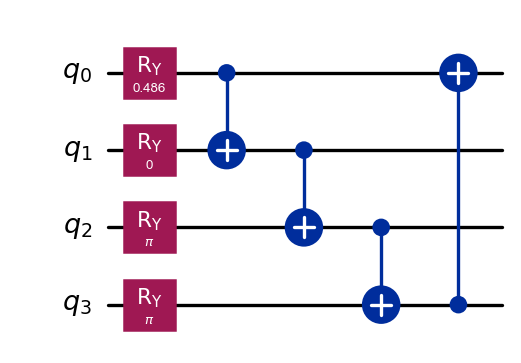

In [ ]:
import matplotlib.pyplot as plt

example_angles = Xtr_q[0]
qc_example = feature_map_angles(example_angles)
try:
    fig = qc_example.draw("mpl")
    plt.show()
except Exception:
    print(qc_example.draw())


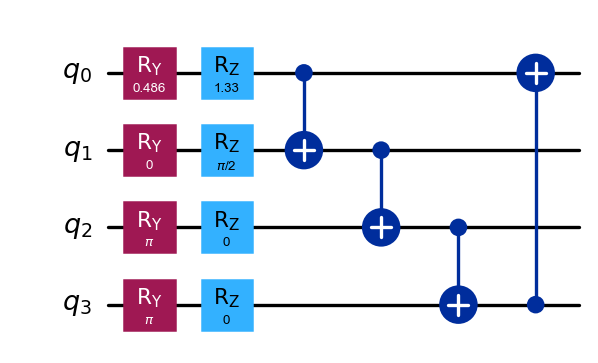

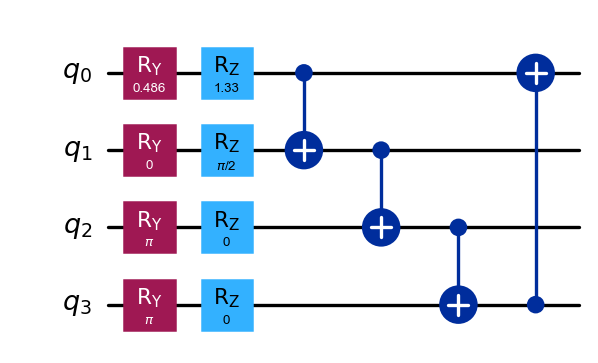

In [ ]:
from qiskit import QuantumCircuit

def enhanced_feature_map_angles(x):
    qc = QuantumCircuit(N_QUBITS)
    for i, angle in enumerate(x):
        qc.ry(angle, i)
        qc.rz(np.pi/2 - angle/2, i)
    for i in range(N_QUBITS - 1):
        qc.cx(i, i + 1)
    qc.cx(N_QUBITS - 1, 0)  
    return qc

example_angles = Xtr_q[0]
qc_enhanced = enhanced_feature_map_angles(example_angles)

qc_enhanced.draw("mpl")


Quantum AUC (calibrated): 0.9273504273504274
Quantum Brier (calibrated): 0.10016487029058611
